In [9]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Crippen

In [5]:
odorants = pd.read_csv("inchi_smiles_odors.csv")

In [6]:
odorants

,InChIKey,SMILES,Odors
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,CC1=CC[C@H](CC1)C(=C)C,"terpenic, peppery, herbal, pine, orange"
1,ULDHMXUKGWMISQ-VIFPVBQESA-N,CC1=CC[C@@H](CC1=O)C(=C)C,"minty, bready, spicy"
2,NOOLISFMXDJSKH-AEJSXWLSSA-N,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mentholic
3,FYGHSUNMUKGBRK-UHFFFAOYSA-N,CC1=C(C(=CC=C1)C)C,NaN
4,LRHPLDYGYMQRHN-UHFFFAOYSA-N,CCCCO,"balsamic, winey, oily, solvent, fermented, swe..."
...,...,...,...
749,LXXNWCFBZHKFPT-UHFFFAOYSA-N,CCOC(=O)C(C)S,"meaty, fruity, sulfurous"
750,XSAYZAUNJMRRIR-UHFFFAOYSA-N,CC(=O)C1=CC2=CC=CC=C2C=C1,"orangeflower, powdery, honey, sweet, floral, o..."
751,JLPUXFOGCDVKGO-TUAOUCFPSA-N,C[C@H]1CCC[C@@]2([C@@]1(CCCC2)O)C,"herbal, musty, earthy, fresh, green"
752,JDLKFOPOAOFWQN-UHFFFAOYSA-N,C=CCSS(=O)CC=C,NaN


In [7]:
odorants.columns

Index(['InChIKey', 'SMILES', 'Odors'], dtype='str')

In [13]:
odorants["mol"] = odorants["SMILES"].apply(Chem.MolFromSmiles)

In [14]:
PROPS = {
    "MW":            Descriptors.MolWt,
    "HeavyAtoms":    Descriptors.HeavyAtomCount,
    "cLogP":         Crippen.MolLogP,
    "MR":            Crippen.MolMR,
    "TPSA":          Descriptors.TPSA,
    "HBD":           Descriptors.NumHDonors,
    "HBA":           Descriptors.NumHAcceptors,
    "RotB":          Descriptors.NumRotatableBonds,
    "Rings":         rdMolDescriptors.CalcNumRings,
    "AromaticRings": rdMolDescriptors.CalcNumAromaticRings,
    "FracCsp3":      Descriptors.FractionCSP3,
    "HeteroAtoms":   rdMolDescriptors.CalcNumHeteroatoms,
    "BertzCT":       Descriptors.BertzCT,
    "NumStereo":     rdMolDescriptors.CalcNumAtomStereoCenters,
}

In [15]:
ODOR_SMARTS = {
    "thiol":      "[#6][SX2H]",
    "sulfide":    "[#6][SX2][#6]",
    "disulfide":  "[#6][SX2][SX2][#6]",
    "aldehyde":   "[CX3H1](=O)[#6]",
    "ketone":     "[#6][CX3](=O)[#6]",
    "ester":      "[CX3](=O)[OX2H0][#6]",
    "lactone":    "[CX3](=O)[OX2H0;R]",
    "carboxyl":   "[CX3](=O)[OX2H1]",
    "alcohol":    "[CX4][OX2H]",
    "phenol":     "[OX2H][c]",
    "ether":      "[OD2]([#6])[#6]",
    "amine":      "[NX3;!$(N[#6]=[O,N,S])]",
    "pyrazine":   "c1cnccn1",
    "furan":      "c1ccoc1",
    "thiazole":   "c1cscn1",
    "conj_enone": "[CX3]=[CX3][CX3]=[OX1]",
}

In [16]:
patterns = {k: Chem.MolFromSmarts(v) for k, v in ODOR_SMARTS.items()}
fr_funcs = {n: getattr(Descriptors, n) for n in dir(Descriptors) if n.startswith("fr_")}

def featurize(m):
    if m is None:
        return pd.Series(dtype=float)
    row = {k: f(m) for k, f in PROPS.items()}
    row.update({f"fg_{k}": len(m.GetSubstructMatches(p)) for k, p in patterns.items()})
    row.update({n: f(m) for n, f in fr_funcs.items()})
    return pd.Series(row)

feats = odorants["mol"].apply(featurize)
feats = feats.loc[:, feats.sum() > 0]          # drop groups absent everywhere
odorants = pd.concat([odorants, feats], axis=1)

print(odorants.shape)

(754, 89)


In [17]:
odorants

,InChIKey,SMILES,Odors,mol,MW,HeavyAtoms,cLogP,MR,TPSA,HBD,...,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_priamide,fr_pyridine,fr_sulfide,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,CC1=CC[C@H](CC1)C(=C)C,"terpenic, peppery, herbal, pine, orange",<rdkit.Chem.rdchem.Mol object at 0x76b124c31850>,136.238,10.0,3.30890,45.9120,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ULDHMXUKGWMISQ-VIFPVBQESA-N,CC1=CC[C@@H](CC1=O)C(=C)C,"minty, bready, spicy",<rdkit.Chem.rdchem.Mol object at 0x76b124c318c0>,150.221,11.0,2.48790,46.3020,17.07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,NOOLISFMXDJSKH-AEJSXWLSSA-N,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mentholic,<rdkit.Chem.rdchem.Mol object at 0x76b124c31930>,156.269,11.0,2.43950,47.3498,20.23,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,FYGHSUNMUKGBRK-UHFFFAOYSA-N,CC1=C(C(=CC=C1)C)C,NaN,<rdkit.Chem.rdchem.Mol object at 0x76b124c319a0>,120.195,9.0,2.61186,40.6530,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,LRHPLDYGYMQRHN-UHFFFAOYSA-N,CCCCO,"balsamic, winey, oily, solvent, fermented, swe...",<rdkit.Chem.rdchem.Mol object at 0x76b124c31a10>,74.123,5.0,0.77880,21.9938,20.23,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749,LXXNWCFBZHKFPT-UHFFFAOYSA-N,CCOC(=O)C(C)S,"meaty, fruity, sulfurous",<rdkit.Chem.rdchem.Mol object at 0x76b12431e2d0>,134.200,8.0,0.86780,35.0810,26.30,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
750,XSAYZAUNJMRRIR-UHFFFAOYSA-N,CC(=O)C1=CC2=CC=CC=C2C=C1,"orangeflower, powdery, honey, sweet, floral, o...",<rdkit.Chem.rdchem.Mol object at 0x76b12431e340>,170.211,13.0,3.04240,53.9525,17.07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
751,JLPUXFOGCDVKGO-TUAOUCFPSA-N,C[C@H]1CCC[C@@]2([C@@]1(CCCC2)O)C,"herbal, musty, earthy, fresh, green",<rdkit.Chem.rdchem.Mol object at 0x76b12431e3b0>,182.307,13.0,3.11780,54.5398,20.23,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
752,JDLKFOPOAOFWQN-UHFFFAOYSA-N,C=CCSS(=O)CC=C,NaN,<rdkit.Chem.rdchem.Mol object at 0x76b12431e420>,162.279,9.0,1.75530,45.8614,17.07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
odorants.columns

Index(['InChIKey', 'SMILES', 'Odors', 'mol', 'MW', 'HeavyAtoms', 'cLogP', 'MR',
       'TPSA', 'HBD', 'HBA', 'RotB', 'Rings', 'AromaticRings', 'FracCsp3',
       'HeteroAtoms', 'BertzCT', 'NumStereo', 'fg_thiol', 'fg_sulfide',
       'fg_disulfide', 'fg_aldehyde', 'fg_ketone', 'fg_ester', 'fg_lactone',
       'fg_carboxyl', 'fg_alcohol', 'fg_phenol', 'fg_ether', 'fg_amine',
       'fg_pyrazine', 'fg_furan', 'fg_thiazole', 'fg_conj_enone', 'fr_Al_COO',
       'fr_Al_OH', 'fr_Al_OH_noTert', 'fr_ArN', 'fr_Ar_COO', 'fr_Ar_N',
       'fr_Ar_NH', 'fr_Ar_OH', 'fr_COO', 'fr_COO2', 'fr_C_O', 'fr_C_O_noCOO',
       'fr_Imine', 'fr_NH0', 'fr_NH1', 'fr_NH2', 'fr_Ndealkylation2',
       'fr_Nhpyrrole', 'fr_SH', 'fr_aldehyde', 'fr_alkyl_halide',
       'fr_allylic_oxid', 'fr_amide', 'fr_aniline', 'fr_aryl_methyl',
       'fr_benzene', 'fr_bicyclic', 'fr_epoxide', 'fr_ester', 'fr_ether',
       'fr_furan', 'fr_guanido', 'fr_halogen', 'fr_imidazole', 'fr_ketone',
       'fr_ketone_Topliss', 'fr_lacton

In [21]:
print(odorants["mol"].isna().sum())                      
print(odorants["Odors"].isna().sum())  # unlabeled molecules                   

0
179


In [23]:
labeled = odorants[odorants["Odors"].notna()].reset_index(drop=True)

# turn "terpenic, peppery, herbal" into a clean list of words
labeled["odor_list"] = labeled["Odors"].apply(
    lambda s: [t.strip().lower() for t in s.split(",") if t.strip()]
)

# explode into one word per row, then one-hot with get_dummies, then group back
Y = pd.get_dummies(labeled["odor_list"].explode()).groupby(level=0).max()

print(Y.shape) #(number of molecules, number of unique odor words)
Y.head()

(575, 147)


,acidic,alcoholic,aldehydic,alliaceous,almond,amber,animal,anise,anisic,apple,...,tomato,tropical,vanilla,vegetable,violet,warm,waxy,weedy,winey,woody
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [24]:
counts = Y.sum().sort_values(ascending=False)
print(counts.head(20))   # most common odor words
print(counts.tail(20))   # rarest odor words

sweet        253
fruity       200
green        173
floral       154
fatty        108
fresh        104
waxy          96
herbal        90
woody         81
citrus        76
oily          66
spicy         56
nutty         51
musty         50
rose          50
powdery       49
sulfurous     46
vegetable     45
apple         43
tropical      43
dtype: int64
tea             6
chemical        6
bergamot        5
hawthorn        5
ozone           5
tomato          5
weedy           5
popcorn         5
brothy          5
horseradish     5
gasoline        5
muguet          5
marine          4
malty           4
celery          4
cedar           4
radish          4
juicy           3
orangeflower    2
cortex          1
dtype: int64


In [25]:
#keep only odor words that appear on at least 5 molecules.
keep_words = counts[counts >= 5].index
Yf = Y[keep_words]

print(Yf.shape)

(575, 139)


In [26]:
#Check if any molecule losses its odor tag
has_label = Yf.any(axis=1)
print(has_label.sum(), "molecules still have at least one odor label")
print((~has_label).sum(), "molecules lost all their labels")

575 molecules still have at least one odor label
0 molecules lost all their labels


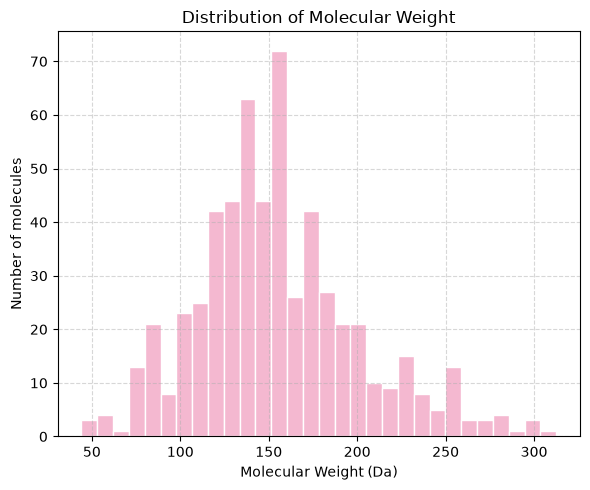

In [210]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

ax.hist(labeled["MW"], bins=30, color="#f4b8d0", edgecolor="white")

ax.set_xlabel("Molecular Weight (Da)")
ax.set_ylabel("Number of molecules")
ax.set_title("Distribution of Molecular Weight")

ax.grid(True, linestyle="--", alpha=0.5)   # dashed, semi-transparent grid lines

plt.tight_layout()
plt.show()

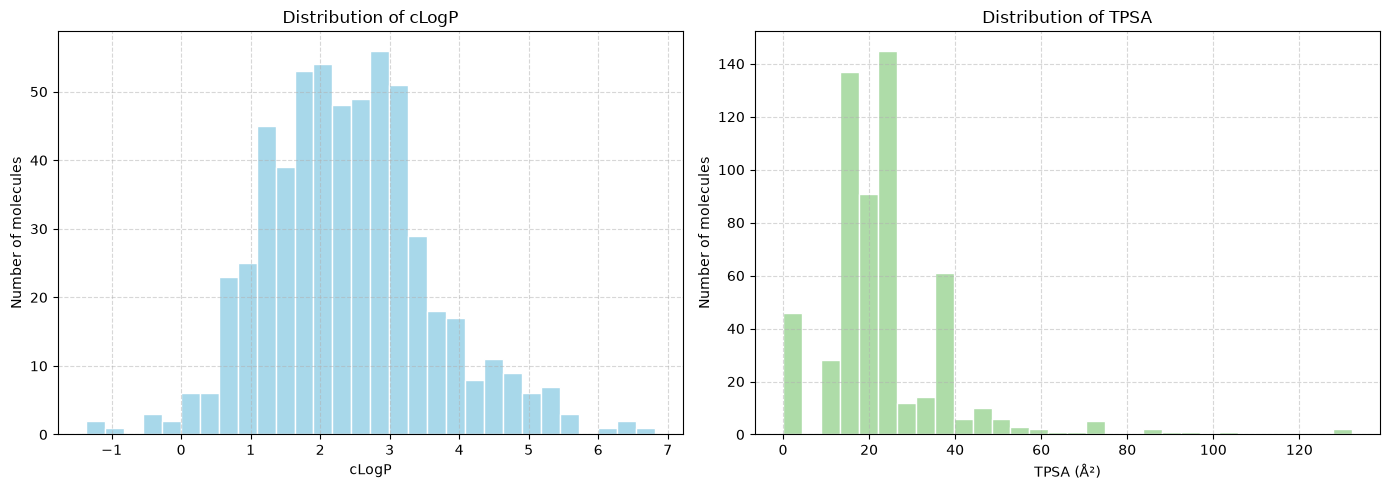

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(labeled["cLogP"], bins=30, color="#a8d8ea", edgecolor="white")  # pastel blue
axes[0].set_xlabel("cLogP")
axes[0].set_ylabel("Number of molecules")
axes[0].set_title("Distribution of cLogP")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].hist(labeled["TPSA"], bins=30, color="#aedca8", edgecolor="white")  # pastel green
axes[1].set_xlabel("TPSA (Å²)")
axes[1].set_ylabel("Number of molecules")
axes[1].set_title("Distribution of TPSA")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [32]:
labeled.sort_values("TPSA", ascending=False)[["SMILES", "TPSA", "MW", "Odors"]].head(5)

,SMILES,TPSA,MW,Odors
432,C(C(=O)O)C(CC(=O)O)(C(=O)O)O,132.13,192.123,odorless
76,CC1=C(C(=C(C(=C1[N+](=O)[O-])C(C)(C)C)[N+](=O)...,129.42,297.267,"soapy, fatty, sweet, dry, musk"
122,CC1=C(C(=C(C(=C1[N+](=O)[O-])C(C)(C)C)[N+](=O)...,103.35,294.307,"powdery, soapy, fatty, floral, dry, musk"
498,CC1=C(C=C(C(=C1[N+](=O)[O-])OC)C(C)(C)C)[N+](=...,95.51,268.269,"musty, sweet, floral, musk"
495,C(CC(=O)O)C(=O)C(=O)O,91.67,146.098,odorless


In [33]:
print(labeled.shape[0] == Yf.shape[0])

True


In [34]:
top_odors = Yf.sum().sort_values(ascending=False).head(15).index
fg_cols = [c for c in labeled.columns if c.startswith("fg_")]
print(top_odors.tolist())
print(fg_cols)

['sweet', 'fruity', 'green', 'floral', 'fatty', 'fresh', 'waxy', 'herbal', 'woody', 'citrus', 'oily', 'spicy', 'nutty', 'musty', 'rose']
['fg_thiol', 'fg_sulfide', 'fg_disulfide', 'fg_aldehyde', 'fg_ketone', 'fg_ester', 'fg_lactone', 'fg_carboxyl', 'fg_alcohol', 'fg_phenol', 'fg_ether', 'fg_amine', 'fg_pyrazine', 'fg_furan', 'fg_thiazole', 'fg_conj_enone']


In [35]:
import numpy as np

rows = []
for fg in fg_cols:
    has_fg = labeled[fg] > 0                     # True if molecule has that group
    row = {}
    for odor in top_odors:
        if has_fg.sum() == 0:
            row[odor] = np.nan
        else:
            row[odor] = Yf.loc[has_fg, odor].mean() * 100   # % of that group with this odor
    rows.append(row)

heat_df = pd.DataFrame(rows, index=fg_cols)
heat_df

,sweet,fruity,green,floral,fatty,fresh,waxy,herbal,woody,citrus,oily,spicy,nutty,musty,rose
fg_thiol,9.090909,18.181818,9.090909,9.090909,9.090909,0.000000,0.000000,0.000000,4.545455,4.545455,9.090909,0.000000,0.000000,0.000000,0.000000
fg_sulfide,30.769231,23.076923,23.076923,0.000000,0.000000,0.000000,0.000000,7.692308,0.000000,0.000000,7.692308,7.692308,15.384615,7.692308,0.000000
fg_disulfide,0.000000,10.000000,30.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000
fg_aldehyde,32.467532,29.870130,62.337662,33.766234,35.064935,36.363636,24.675325,16.883117,11.688312,33.766234,6.493506,9.090909,10.389610,6.493506,6.493506
fg_ketone,47.422680,39.175258,21.649485,29.896907,13.402062,12.371134,5.154639,23.711340,22.680412,4.123711,10.309278,8.247423,8.247423,8.247423,6.185567
fg_ester,66.433566,69.930070,27.972028,32.867133,22.377622,15.384615,30.769231,10.489510,9.790210,7.692308,16.783217,5.594406,4.195804,3.496503,12.587413
fg_lactone,72.413793,37.931034,3.448276,10.344828,51.724138,10.344828,37.931034,3.448276,10.344828,0.000000,34.482759,0.000000,10.344828,6.896552,0.000000
fg_carboxyl,9.090909,22.727273,9.090909,6.818182,38.636364,2.272727,29.545455,0.000000,0.000000,2.272727,6.818182,0.000000,2.272727,2.272727,4.545455
fg_alcohol,48.101266,21.518987,35.443038,43.037975,17.721519,26.582278,17.721519,18.987342,11.392405,24.050633,26.582278,7.594937,3.797468,12.658228,20.253165
fg_phenol,74.193548,9.677419,6.451613,12.903226,0.000000,3.225806,0.000000,12.903226,35.483871,0.000000,3.225806,35.483871,0.000000,9.677419,0.000000


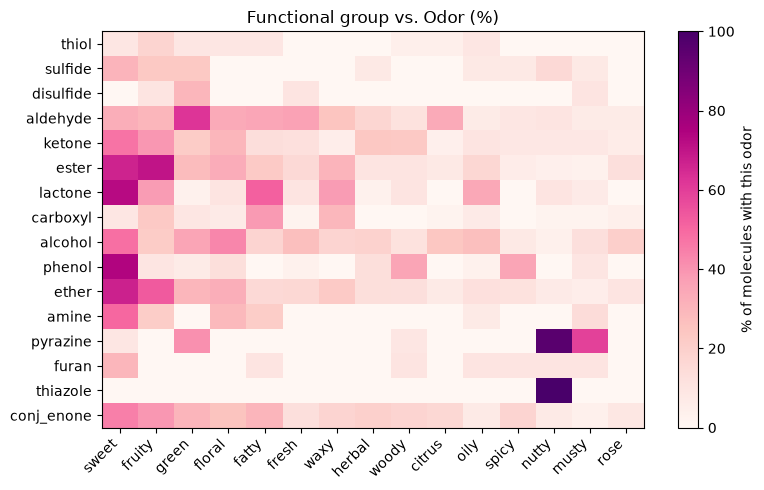

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heat_df.values, cmap="RdPu", aspect="auto")

ax.set_xticks(range(len(heat_df.columns)))
ax.set_xticklabels(heat_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heat_df.index)))
ax.set_yticklabels([g.replace("fg_", "") for g in heat_df.index])  # strip "fg_" prefix

plt.colorbar(im, ax=ax, label="% of molecules with this odor")
ax.set_title("Functional group vs. Odor (%)")
plt.tight_layout()
plt.show()

In [55]:
props_to_use = ["MW", "cLogP", "TPSA", "HBD", "HBA", "RotB", "AromaticRings"]

rows = []
for odor in top_odors:
    has_odor = Yf[odor] > 0
    row = {}
    for prop in props_to_use:
        row[prop] = labeled.loc[has_odor, prop].mean()
    rows.append(row)

prop_heat = pd.DataFrame(rows, index=top_odors)
print(prop_heat)   

                MW     cLogP       TPSA       HBD       HBA      RotB  \
sweet   159.866249  2.334994  26.586047  0.292490  1.818182  3.106719   
fruity  152.654965  2.291191  25.128900  0.195000  1.725000  3.870000   
green   150.195318  2.384784  21.094566  0.208092  1.508671  3.988439   
floral  174.976948  2.783893  24.385844  0.305195  1.597403  3.928571   
fatty   163.059167  2.839387  26.827130  0.305556  1.490741  5.666667   
fresh   154.926260  2.635812  18.536154  0.221154  1.250000  3.817308   
waxy    184.428615  3.339787  25.599375  0.281250  1.552083  6.906250   
herbal  153.494422  2.635346  17.788556  0.211111  1.188889  3.066667   
woody   165.830321  2.753200  19.704074  0.259259  1.345679  2.345679   
citrus  163.862605  3.147424  17.682763  0.276316  1.065789  5.381579   
oily    164.792152  2.761908  24.003788  0.409091  1.560606  5.257576   
spicy   152.967571  2.429983  19.840357  0.303571  1.410714  2.553571   
nutty   126.941608  1.636131  25.125098  0.098039  

In [154]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

original_cmap = plt.colormaps['RdYlBu']

x_steps = np.linspace(0, 1, 256)

pink_dominant_steps = x_steps ** 1.8
colors = original_cmap(pink_dominant_steps)

factor = 0.55
pastel_colors = colors[:, :3] + (1.0 - colors[:, :3]) * factor
pastel_colors = np.column_stack([pastel_colors, colors[:, 3]])

pink_cmap = ListedColormap(pastel_colors, name='PinktRdYlBu')

print("Η παλέτα δημιουργήθηκε!")

Η παλέτα δημιουργήθηκε!


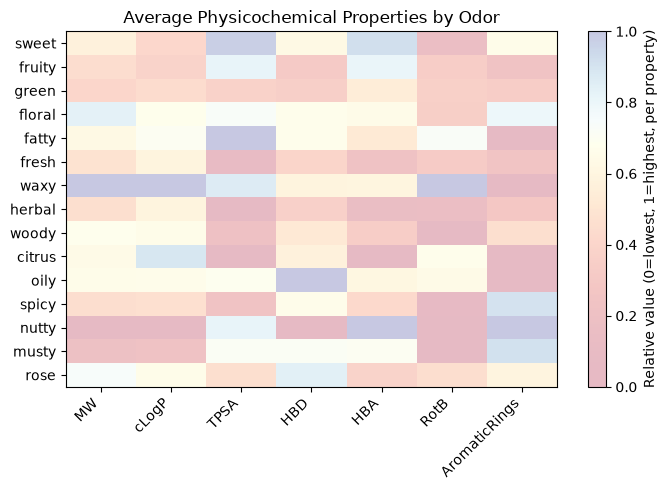

In [159]:
prop_heat_scaled = (prop_heat - prop_heat.min()) / (prop_heat.max() - prop_heat.min())

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(prop_heat_scaled.values, cmap=pink_cmap, aspect="auto", alpha=0.6, vmin=0, vmax=1)

ax.set_xticks(range(len(prop_heat_scaled.columns)))
ax.set_xticklabels(prop_heat_scaled.columns, rotation=45, ha="right")
ax.set_yticks(range(len(prop_heat_scaled.index)))
ax.set_yticklabels(prop_heat_scaled.index)

plt.colorbar(im, ax=ax, label="Relative value (0=lowest, 1=highest, per property)")
ax.set_title("Average Physicochemical Properties by Odor")
plt.tight_layout()
plt.show()

In [54]:
Yf_int = Yf[top_odors].astype(int)
co_occur = Yf_int.T.dot(Yf_int)
co_occur

,sweet,fruity,green,floral,fatty,fresh,waxy,herbal,woody,citrus,oily,spicy,nutty,musty,rose
sweet,253,118,69,87,43,43,50,37,36,30,31,33,14,16,30
fruity,118,200,77,64,46,39,42,26,25,25,26,10,12,14,21
green,69,77,173,58,43,59,40,50,27,33,17,18,19,20,23
floral,87,64,58,154,20,42,32,22,31,36,18,18,3,6,39
fatty,43,46,43,20,108,27,52,14,7,20,34,4,10,6,9
fresh,43,39,59,42,27,104,24,36,26,33,12,13,3,7,16
waxy,50,42,40,32,52,24,96,12,8,31,17,4,6,6,18
herbal,37,26,50,22,14,36,12,90,27,19,13,22,5,11,7
woody,36,25,27,31,7,26,8,27,81,20,5,20,4,6,7
citrus,30,25,33,36,20,33,31,19,20,76,7,9,4,5,17


In [57]:
# Μετατροπή σε ποσοστό
co_occur_pct = co_occur.div(np.diag(co_occur), axis=0) * 100
co_occur_pct

,sweet,fruity,green,floral,fatty,fresh,waxy,herbal,woody,citrus,oily,spicy,nutty,musty,rose
sweet,100.000000,46.640316,27.272727,34.387352,16.996047,16.996047,19.762846,14.624506,14.229249,11.857708,12.252964,13.043478,5.533597,6.324111,11.857708
fruity,59.000000,100.000000,38.500000,32.000000,23.000000,19.500000,21.000000,13.000000,12.500000,12.500000,13.000000,5.000000,6.000000,7.000000,10.500000
green,39.884393,44.508671,100.000000,33.526012,24.855491,34.104046,23.121387,28.901734,15.606936,19.075145,9.826590,10.404624,10.982659,11.560694,13.294798
floral,56.493506,41.558442,37.662338,100.000000,12.987013,27.272727,20.779221,14.285714,20.129870,23.376623,11.688312,11.688312,1.948052,3.896104,25.324675
fatty,39.814815,42.592593,39.814815,18.518519,100.000000,25.000000,48.148148,12.962963,6.481481,18.518519,31.481481,3.703704,9.259259,5.555556,8.333333
fresh,41.346154,37.500000,56.730769,40.384615,25.961538,100.000000,23.076923,34.615385,25.000000,31.730769,11.538462,12.500000,2.884615,6.730769,15.384615
waxy,52.083333,43.750000,41.666667,33.333333,54.166667,25.000000,100.000000,12.500000,8.333333,32.291667,17.708333,4.166667,6.250000,6.250000,18.750000
herbal,41.111111,28.888889,55.555556,24.444444,15.555556,40.000000,13.333333,100.000000,30.000000,21.111111,14.444444,24.444444,5.555556,12.222222,7.777778
woody,44.444444,30.864198,33.333333,38.271605,8.641975,32.098765,9.876543,33.333333,100.000000,24.691358,6.172840,24.691358,4.938272,7.407407,8.641975
citrus,39.473684,32.894737,43.421053,47.368421,26.315789,43.421053,40.789474,25.000000,26.315789,100.000000,9.210526,11.842105,5.263158,6.578947,22.368421


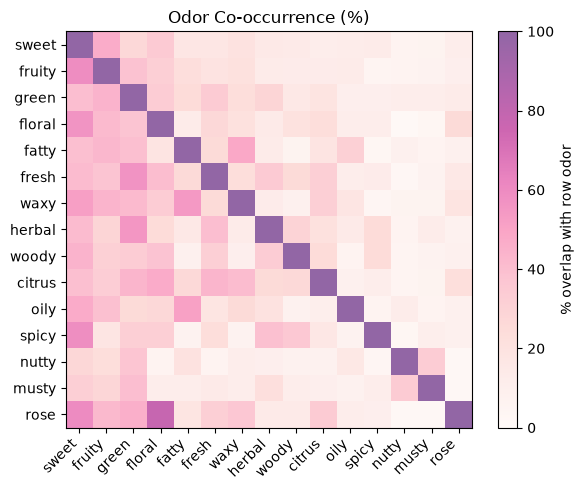

In [138]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(co_occur_pct.values, cmap="RdPu", aspect="auto",alpha=0.6, vmin=0, vmax=100)

ax.set_xticks(range(len(co_occur_pct.columns)))
ax.set_xticklabels(co_occur_pct.columns, rotation=45, ha="right")
ax.set_yticks(range(len(co_occur_pct.index)))
ax.set_yticklabels(co_occur_pct.index)

plt.colorbar(im, ax=ax, label="% overlap with row odor")
ax.set_title("Odor Co-occurrence (%)")
plt.tight_layout()
plt.show()  

In [212]:
#clustering #εμπρός_λοιπόν
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
labeled["fp"] = labeled["mol"].apply(lambda m: morgan_gen.GetFingerprint(m))

from rdkit import DataStructs

fp0 = labeled["fp"].iloc[0]
fp1 = labeled["fp"].iloc[1]   #check for limonene and carvone (first tow molecules)

sim = DataStructs.TanimotoSimilarity(fp0, fp1)
print(sim)

0.47058823529411764


In [71]:
fps = labeled["fp"].tolist()
n = len(fps)

sim_matrix = np.zeros((n, n))
for i in range(n):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps)
    sim_matrix[i] = sims

print(sim_matrix.shape)

(575, 575)


In [213]:
from rdkit.ML.Cluster import Butina

dist_matrix = 1 - sim_matrix

n = dist_matrix.shape[0]
dist_list = []
for i in range(1, n):
    for j in range(i):
        dist_list.append(dist_matrix[i, j])

clusters = Butina.ClusterData(dist_list, n, distThresh=0.6, isDistData=True)

print("Number of clusters:", len(clusters))
print("Sizes of first 10 clusters:", [len(c) for c in clusters[:10]])

Number of clusters: 162
Sizes of first 10 clusters: [69, 13, 4, 32, 6, 22, 2, 13, 20, 7]


In [75]:
#threshold_investigation
sizes = [len(c) for c in clusters]

print("Total clusters:", len(sizes))
print("Singletons (size 1):", sum(1 for s in sizes if s == 1))
print("Largest cluster:", max(sizes))
print("Average cluster size:", np.mean(sizes))

Total clusters: 162
Singletons (size 1): 74
Largest cluster: 69
Average cluster size: 3.549382716049383


In [79]:
for thresh in [0.5, 0.6, 0.7]:
    clusters_t = Butina.ClusterData(dist_list, n, distThresh=thresh, isDistData=True)
    sizes_t = [len(c) for c in clusters_t]
    singles = sum(1 for s in sizes_t if s == 1)
    print(f"threshold={thresh}: clusters={len(sizes_t)}, singletons={singles}, largest={max(sizes_t)}") 

threshold=0.5: clusters=239, singletons=139, largest=50
threshold=0.6: clusters=162, singletons=74, largest=69
threshold=0.7: clusters=96, singletons=32, largest=119


In [81]:
def jaccard(list_a, list_b):
    set_a, set_b = set(list_a), set(list_b)
    if not set_a and not set_b:
        return np.nan
    return len(set_a & set_b) / len(set_a | set_b)

result = jaccard(labeled["odor_list"].iloc[0], labeled["odor_list"].iloc[1])
print("result is:", result)

result is: 0.0


In [87]:
def cluster_odor_consistency(cluster_indices, labeled):
    odor_lists = [labeled["odor_list"].iloc[i] for i in cluster_indices]
    n = len(odor_lists)
    if n < 2:
        return np.nan
    sims = []
    for i in range(n):
        for j in range(i+1, n):
            sims.append(jaccard(odor_lists[i], odor_lists[j]))
    return np.mean(sims)

In [214]:
clusters = Butina.ClusterData(dist_list, n, distThresh=0.6, isDistData=True)
example = [c for c in clusters if len(c) == 6][0]
print(example) #those six rows are grouped togather in one small cluster

(218, 164, 174, 281, 334, 382)


In [89]:
sub = labeled.iloc[list(example)][["SMILES", "Odors"]]
print(sub)

score = cluster_odor_consistency(example, labeled)
print("Odor consistency score:", score)

                SMILES                                              Odors
218       CCCC/C=C/C=O  pungent, fatty, oily, sweet, fresh, green, fru...
164  CCCCC/C=C/C=C/C=O  cucumber, fatty, chicken, oily, melon, citrus,...
174   CCCC/C=C/C=C/C=O  cucumber, fatty, chicken, melon, nutty, green,...
281        CCC/C=C/C=O  clean, herbal, spicy, cheesy, pungent, fatty, ...
334   CCCC/C=C\C=C\C=O                           geranium, pungent, green
382    CCC/C=C/C=C/C=O          fatty, melon, pear, citrus, green, fruity
Odor consistency score: 0.18921172671273628


In [215]:
results = []
for c in clusters:
    if len(c) < 2:
        continue   
    score = cluster_odor_consistency(c, labeled)
    results.append({"cluster_size": len(c), "consistency": score, "members": c})

cluster_df = pd.DataFrame(results)
cluster_df_sorted = cluster_df.sort_values("consistency")
cluster_df_sorted.head(10)

,cluster_size,consistency,members
6,2,0.000000,"(400, 533)"
51,2,0.000000,"(396, 344)"
39,2,0.000000,"(494, 192)"
53,2,0.000000,"(253, 398)"
49,2,0.000000,"(426, 252)"
35,2,0.000000,"(495, 492)"
87,2,0.000000,"(199, 107)"
76,2,0.000000,"(227, 117)"
25,6,0.067935,"(106, 68, 309, 311, 313, 471)"
31,6,0.076899,"(267, 49, 233, 234, 255, 266)"


In [91]:
for idx in cluster_df_sorted.head(10).index:
    members = cluster_df_sorted.loc[idx, "members"]
    print(f"--- cluster {idx} (score={cluster_df_sorted.loc[idx,'consistency']:.3f}) ---")
    print(labeled.iloc[list(members)][["SMILES", "Odors"]])
    print()

--- cluster 6 (score=0.000) ---
           SMILES                                Odors
400     CCCCCCC=C                             gasoline
533  C=CCCCCCCCCO  clean, rose, fresh, waxy, aldehydic

--- cluster 51 (score=0.000) ---
                     SMILES                           Odors
396          CCOC1=CC=CC=C1                   anisic, sweet
344  CCOC1=CC2=CC=CC=C2C=C1  powdery, grape, floral, orange

--- cluster 39 (score=0.000) ---
         SMILES      Odors
494  C(C(=O)O)N   odorless
192  C(C(=O)O)S  sulfurous

--- cluster 53 (score=0.000) ---
       SMILES                                              Odors
253  CC(C)CCO  pungent, fermented, cognac, banana, fruity, et...
398  CC(C)CCN                                             cheesy

--- cluster 49 (score=0.000) ---
             SMILES                                              Odors
426        CCCCOC=O         rummy, plum, brandy, rum, fruity, ethereal
252  CC(C)(CCOC=O)S  coffee, tropical, meaty, onion, roasted, caram..

In [92]:
cluster_df_sorted.head(30)

,cluster_size,consistency,members
6,2,0.000000,"(400, 533)"
51,2,0.000000,"(396, 344)"
39,2,0.000000,"(494, 192)"
53,2,0.000000,"(253, 398)"
49,2,0.000000,"(426, 252)"
35,2,0.000000,"(495, 492)"
87,2,0.000000,"(199, 107)"
76,2,0.000000,"(227, 117)"
25,6,0.067935,"(106, 68, 309, 311, 313, 471)"
31,6,0.076899,"(267, 49, 233, 234, 255, 266)"


In [216]:
#cheking the pair clusters (2 molecules)
pairs_only = cluster_df_sorted[cluster_df_sorted["cluster_size"] == 2].head(15)

for idx in pairs_only.index:
    members = pairs_only.loc[idx, "members"]
    print(f"--- pair (score={pairs_only.loc[idx,'consistency']:.3f}) ---")
    print(labeled.iloc[list(members)][["SMILES", "Odors"]])
    print()

--- pair (score=0.000) ---
           SMILES                                Odors
400     CCCCCCC=C                             gasoline
533  C=CCCCCCCCCO  clean, rose, fresh, waxy, aldehydic

--- pair (score=0.000) ---
                     SMILES                           Odors
396          CCOC1=CC=CC=C1                   anisic, sweet
344  CCOC1=CC2=CC=CC=C2C=C1  powdery, grape, floral, orange

--- pair (score=0.000) ---
         SMILES      Odors
494  C(C(=O)O)N   odorless
192  C(C(=O)O)S  sulfurous

--- pair (score=0.000) ---
       SMILES                                              Odors
253  CC(C)CCO  pungent, fermented, cognac, banana, fruity, et...
398  CC(C)CCN                                             cheesy

--- pair (score=0.000) ---
             SMILES                                              Odors
426        CCCCOC=O         rummy, plum, brandy, rum, fruity, ethereal
252  CC(C)(CCOC=O)S  coffee, tropical, meaty, onion, roasted, caram...

--- pair (score=0.000) ---

In [94]:
discontinuities = [
    {"pair": (494, 192), "change": "N -> S (backbone heteroatom swap)",
     "smell_A": "odorless", "smell_B": "sulfurous"},
    {"pair": (253, 398), "change": "O -> N (alcohol -> amine)",
     "smell_A": "fruity, banana, cognac", "smell_B": "cheesy"},
    {"pair": (199, 107), "change": "+1 ring N (pyridine -> pyrazine)",
     "smell_A": "fishy, burnt", "smell_B": "nutty, roasted"},
    {"pair": (451, 441), "change": "extra S (sulfide -> disulfide)",
     "smell_A": "meaty, garlic, sulfurous", "smell_B": "alliaceous, tropical, fruity"},
    {"pair": (405, 104), "change": "ester alkyl group: methyl -> benzyl",
     "smell_A": "minty, camphoreous", "smell_B": "clean, herbal, balsamic, sweet"},
    {"pair": (440, 437), "change": "stereochemistry only (identical 2D structure)",
     "smell_A": "minty, clean, herbal, citrus, sweet, fresh, fruity", "smell_B": "minty (only)"},
]

discontinuity_df = pd.DataFrame(discontinuities)
discontinuity_df

,pair,change,smell_A,smell_B
0,"(494, 192)",N -> S (backbone heteroatom swap),odorless,sulfurous
1,"(253, 398)",O -> N (alcohol -> amine),"fruity, banana, cognac",cheesy
2,"(199, 107)",+1 ring N (pyridine -> pyrazine),"fishy, burnt","nutty, roasted"
3,"(451, 441)",extra S (sulfide -> disulfide),"meaty, garlic, sulfurous","alliaceous, tropical, fruity"
4,"(405, 104)",ester alkyl group: methyl -> benzyl,"minty, camphoreous","clean, herbal, balsamic, sweet"
5,"(440, 437)",stereochemistry only (identical 2D structure),"minty, clean, herbal, citrus, sweet, fresh, fr...",minty (only)


In [95]:
#larger clusters
big_clusters = cluster_df_sorted[cluster_df_sorted["cluster_size"] >= 5].head(10)

for idx in big_clusters.index:
    members = big_clusters.loc[idx, "members"]
    print(f"--- cluster size={big_clusters.loc[idx,'cluster_size']} (score={big_clusters.loc[idx,'consistency']:.3f}) ---")
    print(labeled.iloc[list(members)][["SMILES", "Odors"]])
    print()

--- cluster size=6 (score=0.068) ---
                    SMILES                                              Odors
106      C1=CC=C(C=C1)CC=O  powdery, hyacinth, honey, chocolate, fermented...
68     CC(CC=O)C1=CC=CC=C1                            hyacinth, herbal, green
309        CSSCC1=CC=CC=C1  cabbage, metallic, onion, green, vegetable, su...
311         CSCC1=CC=CC=C1  chicken, burnt, meaty, beefy, roasted, savory,...
313        C1=CC=C(C=C1)CS  minty, coffee, alliaceous, sharp, onion, garli...
471  CC(CCC1=CC=CC=C1)CC=O         lily, fresh, green, waxy, aldehydic, woody

--- cluster size=6 (score=0.077) ---
                   SMILES                                              Odors
267       CC1=CC=C(C=C1)O                 phenolic, smoky, animal, medicinal
49    CC1=CC=C(C=C1)C(C)C                               citrus, fresh, woody
233  CC1=CC=C(C=C1)C(=C)C  clove, spicy, phenolic, musty, coffee, lemon, ...
234    CC1=CC(=C(C=C1)O)C             phenolic, sharp, smoky, burnt, ro

In [96]:
has_sulfur_fg = (
    (labeled["fg_thiol"] > 0) |
    (labeled["fg_sulfide"] > 0) |
    (labeled["fg_disulfide"] > 0)
)

savory_words = ["sulfurous", "onion", "garlic", "meaty", "alliaceous", "cabbage"]
is_savory = Yf[[w for w in savory_words if w in Yf.columns]].any(axis=1)

print("Sulfur-containing molecules:", has_sulfur_fg.sum())
print("% of sulfur molecules that are savory:", is_savory[has_sulfur_fg].mean() * 100)
print("% of non-sulfur molecules that are savory:", is_savory[~has_sulfur_fg].mean() * 100)

Sulfur-containing molecules: 45
% of sulfur molecules that are savory: 100.0
% of non-sulfur molecules that are savory: 4.150943396226415


In [98]:
has_phenol = labeled["fg_phenol"] > 0

smoky_words = ["smoky", "medicinal", "animal", "leathery"]
is_smoky = Yf[[w for w in smoky_words if w in Yf.columns]].any(axis=1)

print("Phenol-containing molecules:", has_phenol.sum())
print("% of phenol molecules that are smoky/medicinal:", is_smoky[has_phenol].mean() * 100)
print("% of non-phenol molecules that are smoky/medicinal:", is_smoky[~has_phenol].mean() * 100)

Phenol-containing molecules: 31
% of phenol molecules that are smoky/medicinal: 54.83870967741935
% of non-phenol molecules that are smoky/medicinal: 7.169117647058823


In [99]:
has_alcohol = (labeled["fg_alcohol"] > 0) & (labeled["fg_aldehyde"] == 0)
has_aldehyde = (labeled["fg_aldehyde"] > 0) & (labeled["fg_alcohol"] == 0)

rose_words = ["rose", "geranium", "floral"]
citrus_words = ["citrus", "lemon", "orange"]

is_rosy = Yf[[w for w in rose_words if w in Yf.columns]].any(axis=1)
is_citrusy = Yf[[w for w in citrus_words if w in Yf.columns]].any(axis=1)

print("Alcohols:", has_alcohol.sum(), "| Aldehydes:", has_aldehyde.sum())
print("% alcohols that are rosy/floral:", is_rosy[has_alcohol].mean() * 100)
print("% aldehydes that are rosy/floral:", is_rosy[has_aldehyde].mean() * 100)
print("% alcohols that are citrusy:", is_citrusy[has_alcohol].mean() * 100)
print("% aldehydes that are citrusy:", is_citrusy[has_aldehyde].mean() * 100)

Alcohols: 77 | Aldehydes: 75
% alcohols that are rosy/floral: 45.45454545454545
% aldehydes that are rosy/floral: 33.33333333333333
% alcohols that are citrusy: 27.27272727272727
% aldehydes that are citrusy: 37.333333333333336


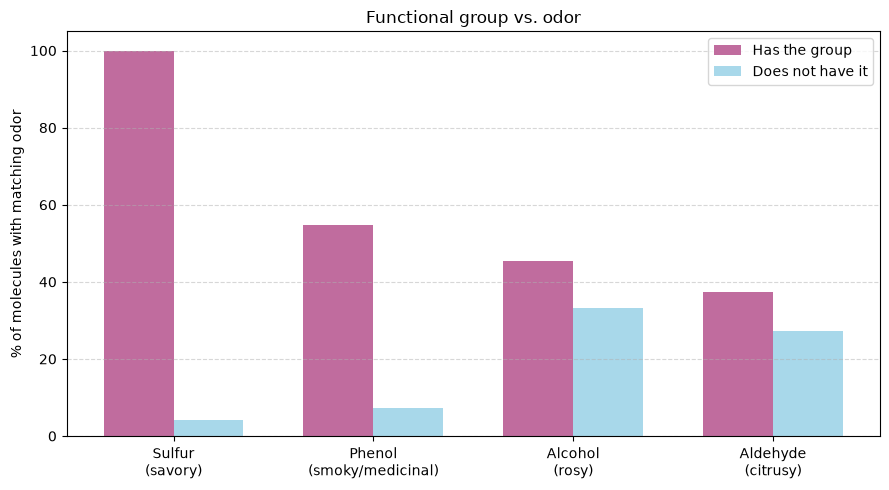

In [101]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Sulfur\n(savory)", "Phenol\n(smoky/medicinal)", "Alcohol\n(rosy)", "Aldehyde\n(citrusy)"]
with_group = [100.0, 54.84, 45.45, 37.33]
without_group = [4.15, 7.17, 33.33, 27.27]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, with_group, width, label="Has the group", color="#c06c9e")
ax.bar(x + width/2, without_group, width, label="Does not have it", color="#a8d8ea")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("% of molecules with matching odor")
ax.set_title("Functional group vs. odor")
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [102]:
savory_no_sulfur = labeled[is_savory & ~has_sulfur_fg]
savory_no_sulfur[["SMILES", "Odors"]]

,SMILES,Odors
57,CC1=NC=CN=C1C,"powdery, musty, coffee, potato, nutty, meaty, ..."
64,CCC1=NC=C(N=C1CC)C,"musty, hazelnut, potato, chocolate, nutty, mea..."
96,COC1=CC=CC=C1O,"spicy, phenolic, smoky, meaty, sweet, savory, ..."
117,CCC(=O)C=C,"peppery, spicy, pungent, alliaceous, radish, o..."
119,CCCCCC(=O)C=C,"herbal, musty, cabbage, metallic, chicken, fis..."
123,CC1C(=O)C(=C(O1)C)OC,"musty, coffee, potato, winey, brandy, meaty, s..."
124,CCC1=NC=CN=C1C(=O)C,"popcorn, musty, hazelnut, potato, nutty, meaty..."
125,CCC1=NC=CN=C1,"musty, coffee, buttery, fermented, nutty, meat..."
173,CCCCCCC/C=C/C=C/C=O,"fatty, citrus, meaty, grapefruit, orange"
230,CC(C)CCCCCCCCCCC=O,"cooked, fatty, citrus, meaty, beefy, animal, s..."


In [103]:
morgan_gen_chiral = rdFingerprintGenerator.GetMorganGenerator(
    radius=2, fpSize=2048, includeChirality=True
)

labeled["fp_chiral"] = labeled["mol"].apply(lambda m: morgan_gen_chiral.GetFingerprint(m))

In [104]:
sim_plain = DataStructs.TanimotoSimilarity(labeled["fp"].loc[440], labeled["fp"].loc[437])
sim_chiral = DataStructs.TanimotoSimilarity(labeled["fp_chiral"].loc[440], labeled["fp_chiral"].loc[437])

print("Plain fingerprint similarity:", sim_plain)
print("Chiral fingerprint similarity:", sim_chiral)

Plain fingerprint similarity: 1.0
Chiral fingerprint similarity: 0.9230769230769231


In [105]:
fps_chiral = labeled["fp_chiral"].tolist()
n = len(fps_chiral)

sim_matrix_chiral = np.zeros((n, n))
for i in range(n):
    sims = DataStructs.BulkTanimotoSimilarity(fps_chiral[i], fps_chiral)
    sim_matrix_chiral[i] = sims

dist_matrix_chiral = 1 - sim_matrix_chiral
dist_list_chiral = []
for i in range(1, n):
    for j in range(i):
        dist_list_chiral.append(dist_matrix_chiral[i, j])

clusters_chiral = Butina.ClusterData(dist_list_chiral, n, distThresh=0.6, isDistData=True)

print("Number of clusters (chiral):", len(clusters_chiral))
print("Number of clusters (plain, for comparison):", len(clusters))

Number of clusters (chiral): 163
Number of clusters (plain, for comparison): 162


In [109]:
#stereoisomersfinding
labeled["inchi_no_stereo"] = labeled["mol"].apply(
    lambda m: Chem.MolToInchi(m).split("/t")[0]
)

stereo_groups = labeled.groupby("inchi_no_stereo").filter(lambda g: len(g) > 1)
print("Molecules that are stereoisomers of something else in the set:", len(stereo_groups))
stereo_groups.groupby("inchi_no_stereo").size().sort_values(ascending=False)

Molecules that are stereoisomers of something else in the set: 53


[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Charges were rearranged

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Charges were rearranged

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Omitted undefined stereo

[14:33:53] WARNING: Omitted undefine

inchi_no_stereo
InChI=1S/C10H14O/c1-7(2)9-5-4-8(3)10(11)6-9/h4,9H,1,5-6H2,2-3H3                   3
InChI=1S/C10H16/c1-7-4-5-8-6-9(7)10(8,2)3/h4,8-9H,5-6H2,1-3H3                     3
InChI=1S/C10H16/c1-7-4-5-8-6-9(7)10(8,2)3/h8-9H,1,4-6H2,2-3H3                     3
InChI=1S/C10H16/c1-8(2)10-6-4-9(3)5-7-10/h4,10H,1,5-7H2,2-3H3                     3
InChI=1S/C10H20O/c1-7(2)9-5-4-8(3)6-10(9)11/h7-11H,4-6H2,1-3H3                    3
InChI=1S/C10H16O/c1-9(2)7-4-5-10(3,6-7)8(9)11/h7H,4-6H2,1-3H3                     3
InChI=1S/C7H16O/c1-3-4-5-6-7(2)8/h7-8H,3-6H2,1-2H3                                3
InChI=1S/C10H20O/c1-9(2)5-4-6-10(3)7-8-11/h5,10-11H,4,6-8H2,1-3H3                 3
InChI=1S/C10H18O/c1-9(2)5-4-6-10(3)7-8-11/h5,8,10H,4,6-7H2,1-3H3                  3
InChI=1S/C10H16/c1-7-8-4-5-9(6-8)10(7,2)3/h8-9H,1,4-6H2,2-3H3                     2
InChI=1S/C10H16/c1-8(2)10-6-4-9(3)5-7-10/h4-6,8,10H,7H2,1-3H3                     2
InChI=1S/C10H16O/c1-7(2)9-5-4-8(3)10(11)6-9/h8-9H,1,4-6H2,2-

In [110]:
stereo_pairs = []
for skeleton, group in stereo_groups.groupby("inchi_no_stereo"):
    rows = group[["SMILES", "Odors", "odor_list"]].to_dict("records")
    stereo_pairs.append({"skeleton": skeleton, "n_isomers": len(rows), "molecules": rows})

print("Total stereo groups:", len(stereo_pairs))

Total stereo groups: 22


In [111]:
stereo_scores = []
for skeleton, group in stereo_groups.groupby("inchi_no_stereo"):
    indices = group.index.tolist()
    score = cluster_odor_consistency(indices, labeled)
    stereo_scores.append({"skeleton": skeleton, "n_isomers": len(indices), "consistency": score})

stereo_score_df = pd.DataFrame(stereo_scores).sort_values("consistency")
stereo_score_df

,skeleton,n_isomers,consistency
20,"InChI=1S/C8H18O/c1-3-4-5-6-7-8(2)9/h8-9H,3-7H2...",2,0.000000
9,"InChI=1S/C10H16O/c1-9(2)7-4-5-10(9,3)8(11)6-7/...",2,0.090909
11,"InChI=1S/C10H18O/c1-8-4-6-9(7-5-8)10(2,3)11/h4...",2,0.125000
6,InChI=1S/C10H16O/c1-7(2)8-4-5-10(3)9(6-8)11-10...,2,0.142857
21,InChI=1S/C9H16O2/c1-3-4-5-8-7(2)6-9(10)11-8/h7...,2,0.142857
18,"InChI=1S/C7H16O/c1-3-4-5-6-7(2)8/h7-8H,3-6H2,1...",3,0.177778
10,InChI=1S/C10H18O/c1-7(2)9-5-4-8(3)6-10(9)11/h7...,2,0.200000
7,InChI=1S/C10H16O/c1-7(2)9-5-4-8(3)10(11)6-9/h8...,2,0.200000
19,"InChI=1S/C8H10O/c1-7(9)8-5-3-2-4-6-8/h2-7,9H,1H3",2,0.200000
4,"InChI=1S/C10H16/c1-8(2)10-6-4-9(3)5-7-10/h4,10...",3,0.203704


In [112]:
print(stereo_score_df.iloc[0]["skeleton"])
labeled[labeled["inchi_no_stereo"] == stereo_score_df.iloc[0]["skeleton"]][["SMILES", "Odors"]]

InChI=1S/C8H18O/c1-3-4-5-6-7-8(2)9/h8-9H,3-7H2,1-2H3


,SMILES,Odors
354,CCCCCCC(C)O,"herbal, spicy, musty, leafy, floral, earthy, f..."
388,CCCCCC[C@H](C)O,"fatty, oily, grape, mushroom, creamy"


In [113]:
for skeleton, group in stereo_groups.groupby("inchi_no_stereo"):
    has_at_symbol = group["SMILES"].str.contains("@")
    print(skeleton[:50], "...", "| stereo-specified:", has_at_symbol.tolist())

InChI=1S/C10H14O/c1-7(2)9-5-4-8(3)10(11)6-9/h4,9H, ... | stereo-specified: [True, True, False]
InChI=1S/C10H16/c1-7-4-5-8-6-9(7)10(8,2)3/h4,8-9H, ... | stereo-specified: [False, True, True]
InChI=1S/C10H16/c1-7-4-5-8-6-9(7)10(8,2)3/h8-9H,1, ... | stereo-specified: [False, True, True]
InChI=1S/C10H16/c1-7-8-4-5-9(6-8)10(7,2)3/h8-9H,1, ... | stereo-specified: [True, True]
InChI=1S/C10H16/c1-8(2)10-6-4-9(3)5-7-10/h4,10H,1, ... | stereo-specified: [True, False, True]
InChI=1S/C10H16/c1-8(2)10-6-4-9(3)5-7-10/h4-6,8,10 ... | stereo-specified: [True, False]
InChI=1S/C10H16O/c1-7(2)8-4-5-10(3)9(6-8)11-10/h8- ... | stereo-specified: [True, False]
InChI=1S/C10H16O/c1-7(2)9-5-4-8(3)10(11)6-9/h8-9H, ... | stereo-specified: [True, False]
InChI=1S/C10H16O/c1-9(2)7-4-5-10(3,6-7)8(9)11/h7H, ... | stereo-specified: [True, False, True]
InChI=1S/C10H16O/c1-9(2)7-4-5-10(9,3)8(11)6-7/h7H, ... | stereo-specified: [False, True]
InChI=1S/C10H18O/c1-7(2)9-5-4-8(3)6-10(9)11/h7-9H, ... | stereo-specified: [True,

In [114]:
clean_skeletons = [
    "InChI=1S/C10H16/c1-7-8-4-5-9(6-8)10(7,2)3/h8-9H,1,4-6H2,2-3H3",
    "InChI=1S/C10H18O/c1-7(2)9-5-4-8(3)6-10(9)11/h7-9H,4-6H2,1-3H3",
    "InChI=1S/C8H10O/c1-7(9)8-5-3-2-4-6-8/h2-7,9H,1H3"
]

for sk in clean_skeletons:
    print("---", sk[:40], "---")
    print(labeled[labeled["inchi_no_stereo"] == sk][["SMILES", "Odors"]])
    print()

--- InChI=1S/C10H16/c1-7-8-4-5-9(6-8)10(7,2) ---
                            SMILES                              Odors
436    CC1([C@H]2CC[C@H](C2)C1=C)C             terpenic, fresh, woody
439  CC1([C@@H]2CC[C@@H](C2)C1=C)C  herbal, camphoreous, fresh, woody

--- InChI=1S/C10H18O/c1-7(2)9-5-4-8(3)6-10(9 ---
                            SMILES  \
131  C[C@@H]1CC[C@H](C(=O)C1)C(C)C   
463  C[C@H]1CC[C@@H](C(=O)C1)C(C)C   

                                                 Odors  
131  minty, cooling, anise, mentholic, herbal, swee...  
463                             minty, mentholic, mint  

--- InChI=1S/C8H10O/c1-7(9)8-5-3-2-4-6-8/h2- ---
                    SMILES                         Odors
384   C[C@H](C1=CC=CC=C1)O         floral, earthy, green
391  C[C@@H](C1=CC=CC=C1)O  hyacinth, strawberry, floral



In [116]:
#subclass specific- breakdown
def assign_class(row):
    if row["fg_ester"] > 0: return "ester"
    if row["fg_aldehyde"] > 0: return "aldehyde"
    if row["fg_ketone"] > 0: return "ketone"
    if row["fg_carboxyl"] > 0: return "acid"
    if row["fg_alcohol"] > 0: return "alcohol"
    if row["fg_thiol"] > 0 or row["fg_sulfide"] > 0 or row["fg_disulfide"] > 0: return "sulfur"
    return "other"

labeled["chem_class"] = labeled.apply(assign_class, axis=1)
print(labeled["chem_class"].value_counts())

chem_class
ester       143
other       115
ketone       95
aldehyde     77
alcohol      72
acid         42
sulfur       31
Name: count, dtype: int64


In [117]:
from itertools import combinations

def class_correlation(class_name):
    idx = labeled[labeled["chem_class"] == class_name].index.tolist()
    struct_sims = []
    odor_sims = []
    for i, j in combinations(idx, 2):
        struct_sims.append(DataStructs.TanimotoSimilarity(labeled["fp"].loc[i], labeled["fp"].loc[j]))
        odor_sims.append(jaccard(labeled["odor_list"].loc[i], labeled["odor_list"].loc[j]))
    corr = np.corrcoef(struct_sims, odor_sims)[0, 1]
    return corr, len(struct_sims)

for cls in ["ester", "ketone", "aldehyde", "alcohol", "acid", "sulfur"]:
    corr, n_pairs = class_correlation(cls)
    print(f"{cls}: correlation = {corr:.3f}  (n pairs = {n_pairs})")

ester: correlation = 0.362  (n pairs = 10153)
ketone: correlation = 0.341  (n pairs = 4465)
aldehyde: correlation = 0.363  (n pairs = 2926)
alcohol: correlation = 0.264  (n pairs = 2556)
acid: correlation = 0.355  (n pairs = 861)
sulfur: correlation = 0.227  (n pairs = 465)


In [118]:
# Question2_different approach 
Yf_arr = Yf.values.astype(int)
intersection = Yf_arr @ Yf_arr.T
row_sums = Yf_arr.sum(axis=1)
union = row_sums[:, None] + row_sums[None, :] - intersection
odor_sim_matrix = np.divide(intersection, union, out=np.zeros_like(intersection, dtype=float), where=union != 0)

print(odor_sim_matrix.shape)

(575, 575)


In [217]:
struct_thresh = 0.5   # structurally similar
odor_thresh = 0.1      # different smell

cliff_pairs = []
n = len(labeled)
for i in range(n):
    for j in range(i+1, n):
        s = sim_matrix[i, j]
        o = odor_sim_matrix[i, j]
        if s >= struct_thresh and o <= odor_thresh:
            cliff_pairs.append((labeled.index[i], labeled.index[j], s, o))

cliff_df = pd.DataFrame(cliff_pairs, columns=["mol_i", "mol_j", "struct_sim", "odor_sim"])
print("Number of cliff pairs found:", len(cliff_df))

Number of cliff pairs found: 563


In [120]:
#which group differs in each pair
fg_cols_list = [c for c in labeled.columns if c.startswith("fg_")]

def fg_diff(i, j):
    diffs = []
    for fg in fg_cols_list:
        has_i = labeled.loc[i, fg] > 0
        has_j = labeled.loc[j, fg] > 0
        if has_i != has_j:
            diffs.append(fg.replace("fg_", ""))
    return diffs

cliff_df["fg_changed"] = cliff_df.apply(lambda row: fg_diff(row["mol_i"], row["mol_j"]), axis=1)
cliff_df.head()

,mol_i,mol_j,struct_sim,odor_sim,fg_changed
0,0,438,0.575758,0.076923,"[aldehyde, conj_enone]"
1,3,4,0.714286,0.066667,[]
2,3,5,0.714286,0.058824,[]
3,3,132,0.714286,0.076923,[]
4,3,149,0.714286,0.050000,[]


In [121]:
print(labeled.loc[[3, 4]][["SMILES", "Odors"]])

          SMILES                                              Odors
3          CCCCO  balsamic, winey, oily, solvent, fermented, swe...
4  CCCCCCCCCCCCO  soapy, honey, fatty, oily, citrus, floral, coc...


In [123]:
from collections import Counter
def diff_reason(i, j):
    fgs = fg_diff(i, j)
    if fgs:
        return fgs
    mw_diff = abs(labeled.loc[i, "MW"] - labeled.loc[j, "MW"])
    if mw_diff > 50:
        return ["chain_length_or_size"]
    return ["other_unexplained"]

cliff_df["reason"] = cliff_df.apply(lambda row: diff_reason(row["mol_i"], row["mol_j"]), axis=1)

all_reasons = [r for reasons in cliff_df["reason"] for r in reasons]
reason_tally = pd.Series(Counter(all_reasons)).sort_values(ascending=False)
print(reason_tally)

chain_length_or_size    171
ester                   158
ether                   158
carboxyl                146
ketone                  127
other_unexplained       106
conj_enone               25
alcohol                  25
aldehyde                 24
lactone                   9
sulfide                   8
thiol                     7
phenol                    3
pyrazine                  1
disulfide                 1
dtype: int64


In [124]:
# combine ester+ether since they overlap (ether SMARTS also matches ester oxygens)
reason_tally_fixed = reason_tally.copy()
reason_tally_fixed["ester_or_ether"] = reason_tally_fixed["ester"]  # same count, just relabel
reason_tally_fixed = reason_tally_fixed.drop(["ester", "ether"])

# how many labeled molecules actually contain each group
group_counts = {
    "ester_or_ether": ((labeled["fg_ester"] > 0) | (labeled["fg_ether"] > 0)).sum(),
    "carboxyl": (labeled["fg_carboxyl"] > 0).sum(),
    "ketone": (labeled["fg_ketone"] > 0).sum(),
    "alcohol": (labeled["fg_alcohol"] > 0).sum(),
    "aldehyde": (labeled["fg_aldehyde"] > 0).sum(),
    "conj_enone": (labeled["fg_conj_enone"] > 0).sum(),
    "lactone": (labeled["fg_lactone"] > 0).sum(),
    "sulfide": (labeled["fg_sulfide"] > 0).sum(),
    "thiol": (labeled["fg_thiol"] > 0).sum(),
    "phenol": (labeled["fg_phenol"] > 0).sum(),
    "pyrazine": (labeled["fg_pyrazine"] > 0).sum(),
    "disulfide": (labeled["fg_disulfide"] > 0).sum(),
}

rate_rows = []
for group, cliff_count in reason_tally_fixed.items():
    if group in group_counts and group_counts[group] > 0:
        rate_rows.append({
            "group": group,
            "cliff_count": cliff_count,
            "n_molecules": group_counts[group],
            "cliffs_per_molecule": cliff_count / group_counts[group]
        })

rate_df = pd.DataFrame(rate_rows).sort_values("cliffs_per_molecule", ascending=False)
rate_df

,group,cliff_count,n_molecules,cliffs_per_molecule
0,carboxyl,146,44,3.318182
1,ketone,127,97,1.309278
11,ester_or_ether,158,205,0.770732
6,sulfide,8,13,0.615385
2,conj_enone,25,56,0.446429
7,thiol,7,22,0.318182
3,alcohol,25,79,0.316456
4,aldehyde,24,77,0.311688
5,lactone,9,29,0.310345
10,disulfide,1,10,0.100000


In [125]:
carboxyl_cliffs = cliff_df[cliff_df["reason"].apply(lambda r: "carboxyl" in r)]
print("Number of carboxylic acid cliffs:", len(carboxyl_cliffs))

for _, row in carboxyl_cliffs.head(8).iterrows():
    i, j = row["mol_i"], row["mol_j"]
    print(f"--- struct_sim={row['struct_sim']:.2f}, odor_sim={row['odor_sim']:.2f} ---")
    print(labeled.loc[[i, j]][["SMILES", "Odors"]])
    print()

Number of carboxylic acid cliffs: 146
--- struct_sim=0.52, odor_sim=0.09 ---
              SMILES                                              Odors
7    CCCCC(=O)C(=O)C                cheesy, fatty, buttery, oily, sweet
115       CCCCC(=O)O  acidic, cheesy, tobacco, milky, sharp, fruity,...

--- struct_sim=0.50, odor_sim=0.08 ---
        SMILES                                              Odors
10  CCCC(=O)CC  rummy, winey, grape, sweet, waxy, fruity, ethe...
16   CCCC(=O)O        cheesy, buttery, sharp, dairy, fruity, sour

--- struct_sim=0.52, odor_sim=0.10 ---
                     SMILES                                              Odors
18        CCCCCCCCCCCC(=O)O                        fatty, coconut, fresh, waxy
21  CCCCCCCCCCCCCCCC(=O)OCC  balsamic, milky, oily, sweet, waxy, fruity, cr...

--- struct_sim=0.52, odor_sim=0.07 ---
               SMILES                                              Odors
18  CCCCCCCCCCCC(=O)O                        fatty, coconut, fresh, waxy
23    

In [126]:
sour_words = ["acidic", "cheesy", "sour", "sharp", "pungent"]
fruity_words = ["fruity", "winey", "fermented", "ripe", "estery"]

def has_words(idx, words):
    return any(labeled.loc[idx, "Odors"].lower().find(w) != -1 for w in words) if pd.notna(labeled.loc[idx, "Odors"]) else False

count_matching_pattern = 0
for _, row in carboxyl_cliffs.iterrows():
    i, j = row["mol_i"], row["mol_j"]
    i_is_acid = labeled.loc[i, "fg_carboxyl"] > 0
    acid_idx, other_idx = (i, j) if i_is_acid else (j, i)

    acid_is_sour = has_words(acid_idx, sour_words)
    other_is_fruity = has_words(other_idx, fruity_words)

    if acid_is_sour and other_is_fruity:
        count_matching_pattern += 1

print(f"{count_matching_pattern} / {len(carboxyl_cliffs)} acid cliffs match the sour-acid -> fruity-ester pattern")
print(f"That's {count_matching_pattern/len(carboxyl_cliffs)*100:.1f}%")

59 / 146 acid cliffs match the sour-acid -> fruity-ester pattern
That's 40.4%


In [127]:
#Exctented vacabulary
acid_side_words = Counter()
other_side_words = Counter()

for _, row in carboxyl_cliffs.iterrows():
    i, j = row["mol_i"], row["mol_j"]
    i_is_acid = labeled.loc[i, "fg_carboxyl"] > 0
    acid_idx, other_idx = (i, j) if i_is_acid else (j, i)

    acid_side_words.update(labeled.loc[acid_idx, "odor_list"])
    other_side_words.update(labeled.loc[other_idx, "odor_list"])

print("Most common words on the ACID side:")
print(pd.Series(acid_side_words).sort_values(ascending=False).head(15))
print("\nMost common words on the OTHER (non-acid) side:")
print(pd.Series(other_side_words).sort_values(ascending=False).head(15))

Most common words on the ACID side:
fatty        112
waxy          98
cheesy        68
odorless      48
sour          36
coconut       33
dairy         27
creamy        22
oily          21
pineapple     16
fresh         13
vegetable     13
citrus        12
soapy         11
nutty         11
dtype: int64

Most common words on the OTHER (non-acid) side:
fruity       126
sweet         85
green         85
herbal        59
waxy          51
floral        47
winey         46
apple         38
banana        33
oily          31
fatty         28
fresh         28
pineapple     25
cheesy        25
ketonic       24
dtype: int64


In [128]:
#Re-test
sour_words_v2 = ["fatty", "waxy", "cheesy", "sour", "coconut", "dairy", "creamy"]
fruity_words_v2 = ["fruity", "sweet", "green", "floral", "winey", "apple", "banana", "pineapple"]

count_v2 = 0
for _, row in carboxyl_cliffs.iterrows():
    i, j = row["mol_i"], row["mol_j"]
    i_is_acid = labeled.loc[i, "fg_carboxyl"] > 0
    acid_idx, other_idx = (i, j) if i_is_acid else (j, i)

    acid_match = has_words(acid_idx, sour_words_v2)
    other_match = has_words(other_idx, fruity_words_v2)

    if acid_match and other_match:
        count_v2 += 1

print(f"{count_v2} / {len(carboxyl_cliffs)} = {count_v2/len(carboxyl_cliffs)*100:.1f}%")

111 / 146 = 76.0%


In [129]:
#what is in the remaining 24%
unmatched = []
for _, row in carboxyl_cliffs.iterrows():
    i, j = row["mol_i"], row["mol_j"]
    i_is_acid = labeled.loc[i, "fg_carboxyl"] > 0
    acid_idx, other_idx = (i, j) if i_is_acid else (j, i)

    acid_match = has_words(acid_idx, sour_words_v2)
    other_match = has_words(other_idx, fruity_words_v2)

    if not (acid_match and other_match):
        unmatched.append({"acid_idx": acid_idx, "other_idx": other_idx})

unmatched_df = pd.DataFrame(unmatched)
print(len(unmatched_df))

for _, row in unmatched_df.head(10).iterrows():
    a, o = row["acid_idx"], row["other_idx"]
    print(labeled.loc[[a, o]][["SMILES", "Odors"]])
    print()

35
                     SMILES                                              Odors
44  CCCCCCCCCCCCCCCCCC(=O)O                                           odorless
19        CCCCCCCCCC(=O)OCC  fatty, winey, oily, grape, brandy, nutty, cogn...

                     SMILES                                              Odors
44  CCCCCCCCCCCCCCCCCC(=O)O                                           odorless
20      CCCCCCCCCCCC(=O)OCC  clean, soapy, fatty, oily, sweet, floral, waxy...

                     SMILES                                              Odors
44  CCCCCCCCCCCCCCCCCC(=O)O                                           odorless
21  CCCCCCCCCCCCCCCC(=O)OCC  balsamic, milky, oily, sweet, waxy, fruity, cr...

                     SMILES                                              Odors
44  CCCCCCCCCCCCCCCCCC(=O)O                                           odorless
23          CCCCCCCC(=O)OCC  apricot, musty, winey, pear, brandy, dairy, pi...

                     SMILES                  

In [130]:
# Pink and blue bar plot cheking
# sulfur -> savory, but WITHOUT a sulfur group
savory_no_sulfur = labeled[is_savory & ~has_sulfur_fg]
print("--- Savory without sulfur ---")
print(savory_no_sulfur[["SMILES", "Odors"]])
print()

# phenol -> smoky/medicinal, but WITHOUT a phenol group
smoky_no_phenol = labeled[is_smoky & ~has_phenol]
print("--- Smoky/medicinal without phenol ---")
print(smoky_no_phenol[["SMILES", "Odors"]])
print()

# alcohol -> rosy/floral, but WITHOUT an alcohol group
has_alcohol_only = labeled["fg_alcohol"] > 0
rosy_no_alcohol = labeled[is_rosy & ~has_alcohol_only]
print("--- Rosy/floral without alcohol ---")
print(rosy_no_alcohol[["SMILES", "Odors"]])
print()

# aldehyde -> citrusy, but WITHOUT an aldehyde group
has_aldehyde_only = labeled["fg_aldehyde"] > 0
citrusy_no_aldehyde = labeled[is_citrusy & ~has_aldehyde_only]
print("--- Citrusy without aldehyde ---")
print(citrusy_no_aldehyde[["SMILES", "Odors"]])

--- Savory without sulfur ---
                         SMILES  \
57                CC1=NC=CN=C1C   
64           CCC1=NC=C(N=C1CC)C   
96               COC1=CC=CC=C1O   
117                  CCC(=O)C=C   
119               CCCCCC(=O)C=C   
123        CC1C(=O)C(=C(O1)C)OC   
124         CCC1=NC=CN=C1C(=O)C   
125               CCC1=NC=CN=C1   
173         CCCCCCC/C=C/C=C/C=O   
230          CC(C)CCCCCCCCCCC=O   
244            CCCCCC1=CC=CC=N1   
261           C=CC1=CC=C(C=C1)O   
277                       CSSSC   
280                   CCCSSSCCC   
301                     CCCSSSC   
305                       CCC=O   
316               C1=COC(=C1)CO   
377                   C1=CSC=N1   
378         C1=CC=C2C(=C1)N=CS2   
385                  CCCCC(=O)C   
397  C[C@@H]1CCC(=C(C)C)C(=O)C1   
492             C(C(=O)C(=O)O)O   

                                                 Odors  
57   powdery, musty, coffee, potato, nutty, meaty, ...  
64   musty, hazelnut, potato, chocolate, nutty, me

In [160]:
rosy_no_alcohol_fg_counts = {
    fg: (rosy_no_alcohol[fg] > 0).sum()
    for fg in fg_cols_list
}
pd.Series(rosy_no_alcohol_fg_counts).sort_values(ascending=False)

fg_ether         73
fg_ester         52
fg_ketone        31
fg_aldehyde      25
fg_conj_enone    16
fg_amine          4
fg_phenol         4
fg_lactone        3
fg_carboxyl       3
fg_thiol          2
fg_sulfide        0
fg_disulfide      0
fg_alcohol        0
fg_pyrazine       0
fg_furan          0
fg_thiazole       0
dtype: int64

In [161]:
rosy_no_alcohol[rosy_no_alcohol["fg_thiol"] > 0][["SMILES", "Odors"]]

,SMILES,Odors
258,CCCC(CCOC(=O)C)S,"raspberry, tropical, pear, floral, grapefruit,..."
312,CC(C1=CC=CC=C1)S,"tropical, meaty, floral, sulfurous"


In [163]:
citrusy_no_aldehyde_fg_counts = {
    fg: (citrusy_no_aldehyde[fg] > 0).sum()
    for fg in fg_cols_list
}
print(pd.Series(citrusy_no_aldehyde_fg_counts).sort_values(ascending=False))
print("Total molecules in this list:", len(citrusy_no_aldehyde))

fg_alcohol       21
fg_ether         18
fg_ester         14
fg_ketone         7
fg_conj_enone     2
fg_amine          1
fg_thiol          1
fg_carboxyl       1
fg_lactone        0
fg_sulfide        0
fg_disulfide      0
fg_aldehyde       0
fg_phenol         0
fg_pyrazine       0
fg_furan          0
fg_thiazole       0
dtype: int64
Total molecules in this list: 61


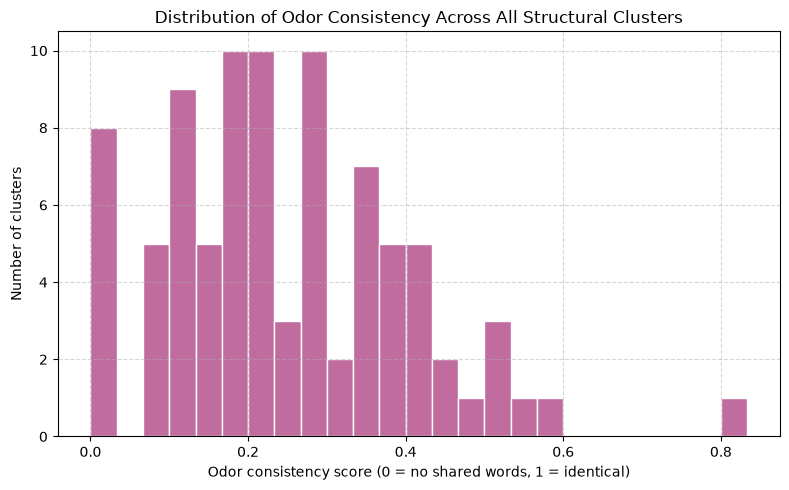

In [164]:
#distribution of odor consistency across all structural clusters.
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(cluster_df["consistency"].dropna(), bins=25, color="#c06c9e", edgecolor="white")
ax.set_xlabel("Odor consistency score (0 = no shared words, 1 = identical)")
ax.set_ylabel("Number of clusters")
ax.set_title("Distribution of Odor Consistency Across All Structural Clusters")
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

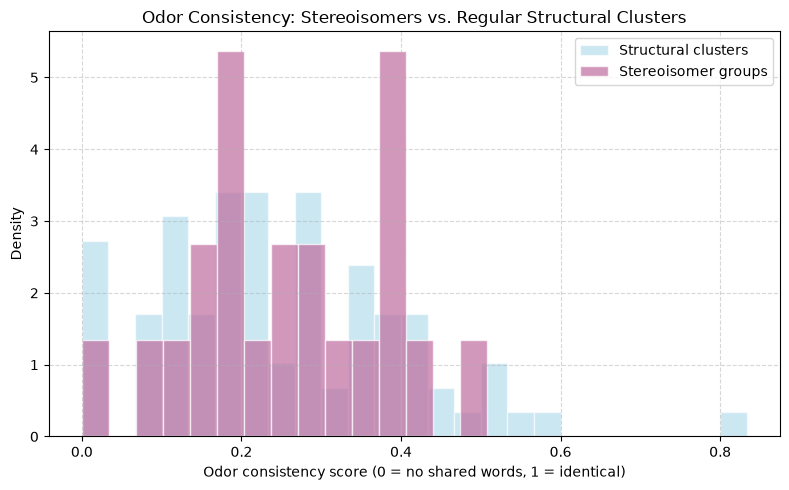

In [166]:
#Effect of stereochemistry
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(cluster_df["consistency"].dropna(), bins=25, color="#a8d8ea", edgecolor="white",
        alpha=0.6, label="Structural clusters", density=True) #morgan fingerprints
ax.hist(stereo_score_df["consistency"].dropna(), bins=15, color="#c06c9e", edgecolor="white",
        alpha=0.7, label="Stereoisomer groups", density=True) #indentical molecules

ax.set_xlabel("Odor consistency score (0 = no shared words, 1 = identical)")
ax.set_ylabel("Density")
ax.set_title("Odor Consistency: Stereoisomers vs. Regular Structural Clusters")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

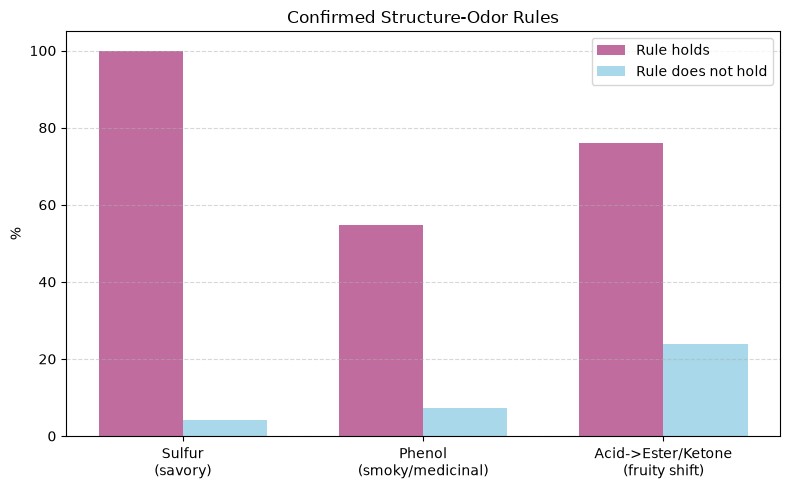

In [168]:
fig, ax = plt.subplots(figsize=(8, 5))

labels = ["Sulfur\n(savory)", "Phenol\n(smoky/medicinal)", "Acid->Ester/Ketone\n(fruity shift)"]
with_group = [100.0, 54.84, 76.0]
without_group = [4.15, 7.17, 24.0]

x = np.arange(len(labels))
width = 0.35

ax.bar(x - width/2, with_group, width, label="Rule holds", color="#c06c9e")
ax.bar(x + width/2, without_group, width, label="Rule does not hold", color="#a8d8ea")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("%")
ax.set_title("Confirmed Structure-Odor Rules")
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

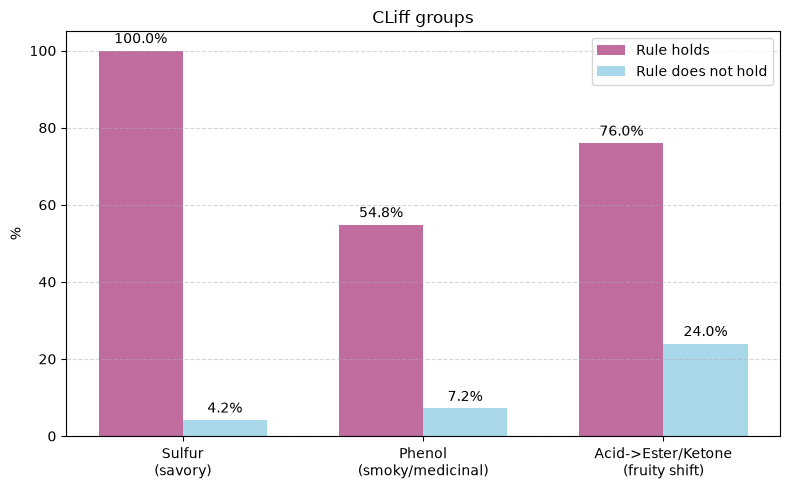

In [170]:
fig, ax = plt.subplots(figsize=(8, 5))

labels = ["Sulfur\n(savory)", "Phenol\n(smoky/medicinal)", "Acid->Ester/Ketone\n(fruity shift)"]
with_group = [100.0, 54.84, 76.0]
without_group = [4.15, 7.17, 24.0]

x = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, with_group, width, label="Rule holds", color="#c06c9e")
bars2 = ax.bar(x + width/2, without_group, width, label="Rule does not hold", color="#a8d8ea")

ax.bar_label(bars1, fmt="%.1f%%", padding=3)
ax.bar_label(bars2, fmt="%.1f%%", padding=3)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("%")
ax.set_title("CLiff groups")
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [172]:
has_acid = labeled["fg_carboxyl"] > 0
sour_words_check = ["fatty", "waxy", "cheesy", "sour", "coconut", "dairy", "creamy"]
is_sour = Yf[[w for w in sour_words_check if w in Yf.columns]].any(axis=1)

is_sour_full = pd.Series(
    labeled.index.map(lambda i: has_words(i, sour_words_check)),
    index=labeled.index
)

print("% of acid molecules that are fatty/sour/cheesy:", is_sour_full[has_acid].mean() * 100)
print("% of non-acid molecules that are fatty/sour/cheesy:", is_sour_full[~has_acid].mean() * 100)

% of acid molecules that are fatty/sour/cheesy: 70.45454545454545
% of non-acid molecules that are fatty/sour/cheesy: 30.32015065913371


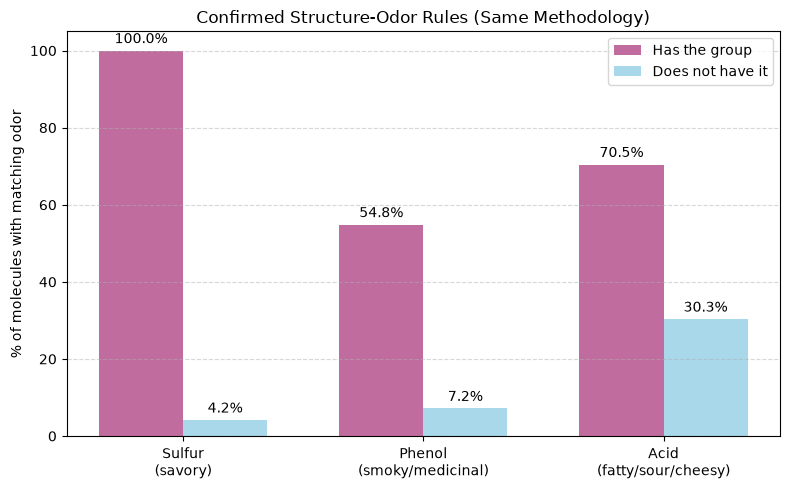

In [173]:
fig, ax = plt.subplots(figsize=(8, 5))

labels = ["Sulfur\n(savory)", "Phenol\n(smoky/medicinal)", "Acid\n(fatty/sour/cheesy)"]
with_group = [100.0, 54.84, 70.45]
without_group = [4.15, 7.17, 30.32]

x = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, with_group, width, label="Has the group", color="#c06c9e")
bars2 = ax.bar(x + width/2, without_group, width, label="Does not have it", color="#a8d8ea")

ax.bar_label(bars1, fmt="%.1f%%", padding=3)
ax.bar_label(bars2, fmt="%.1f%%", padding=3)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("% of molecules with matching odor")
ax.set_title("Confirmed Structure-Odor Rules (Same Methodology)")
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [174]:
sour_no_acid = labeled[is_sour_full & ~has_acid]
print("Count:", len(sour_no_acid))
sour_no_acid[["SMILES", "Odors"]]

Count: 161


,SMILES,Odors
4,CCCCCCCCCCCCO,"soapy, honey, fatty, oily, citrus, floral, coc..."
5,CCCCCCCCO,"fatty, citrus, sweet, floral, coconut, rose, g..."
7,CCCCC(=O)C(=O)C,"cheesy, fatty, buttery, oily, sweet"
9,CCC(C)CO,"leathery, fatty, winey, solvent, fermented, et..."
10,CCCC(=O)CC,"rummy, winey, grape, sweet, waxy, fruity, ethe..."
...,...,...
557,CCCCCCCCC1CCCC(=O)O1,"musty, fatty, milky, buttery, oily, dairy, creamy"
558,CCC(=O)OC/C=C(\C)/CCC=C(C)C,"geranium, powdery, honey, tropical, grape, cit..."
561,CCCC(=O)OC/C=C(\C)/CCC=C(C)C,"raspberry, apricot, tropical, peach, sweet, ro..."
563,CC1=C(C(=C(C(=C1C)[N+](=O)[O-])C(C)(C)C)[N+](=...,"powdery, fatty, sweet, musk"


In [175]:
sour_no_acid_fg_counts = {
    fg: (sour_no_acid[fg] > 0).sum()
    for fg in fg_cols_list
}
print(pd.Series(sour_no_acid_fg_counts).sort_values(ascending=False))
print("Total:", len(sour_no_acid))

fg_ether         65
fg_ester         60
fg_aldehyde      41
fg_ketone        23
fg_alcohol       23
fg_lactone       22
fg_conj_enone    19
fg_amine          6
fg_sulfide        3
fg_thiol          3
fg_phenol         2
fg_furan          1
fg_carboxyl       0
fg_disulfide      0
fg_pyrazine       0
fg_thiazole       0
dtype: int64
Total: 161


In [176]:
#what if a molecule belongs to more than two chemical groups
labeled["n_groups"] = labeled[fg_cols_list].gt(0).sum(axis=1)
print(labeled["n_groups"].value_counts().sort_index())

n_groups
0     36
1    280
2    207
3     48
4      4
Name: count, dtype: int64


In [177]:
def class_correlation_v2(fg_col):
    idx = labeled[labeled[fg_col] > 0].index.tolist()
    struct_sims = []
    odor_sims = []
    for i, j in combinations(idx, 2):
        struct_sims.append(DataStructs.TanimotoSimilarity(labeled["fp"].loc[i], labeled["fp"].loc[j]))
        odor_sims.append(jaccard(labeled["odor_list"].loc[i], labeled["odor_list"].loc[j]))
    if len(struct_sims) < 2:
        return np.nan, len(struct_sims)
    corr = np.corrcoef(struct_sims, odor_sims)[0, 1]
    return corr, len(struct_sims)

for fg, name in [("fg_ester", "ester"), ("fg_ketone", "ketone"), ("fg_aldehyde", "aldehyde"),
                  ("fg_alcohol", "alcohol"), ("fg_carboxyl", "acid"),
                  ("fg_thiol", "thiol"), ("fg_sulfide", "sulfide"), ("fg_disulfide", "disulfide")]:
    corr, n_pairs = class_correlation_v2(fg)
    print(f"{name}: correlation = {corr:.3f}  (n pairs = {n_pairs})")

ester: correlation = 0.362  (n pairs = 10153)
ketone: correlation = 0.346  (n pairs = 4656)
aldehyde: correlation = 0.363  (n pairs = 2926)
alcohol: correlation = 0.286  (n pairs = 3081)
acid: correlation = 0.347  (n pairs = 946)
thiol: correlation = 0.143  (n pairs = 231)
sulfide: correlation = 0.164  (n pairs = 78)
disulfide: correlation = 0.511  (n pairs = 45)


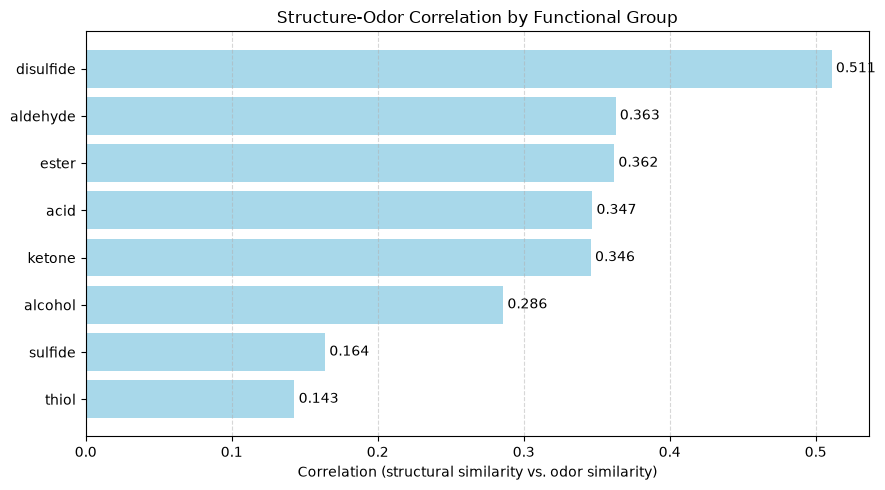

In [179]:
fig, ax = plt.subplots(figsize=(9, 5))

classes = ["ester", "aldehyde", "acid", "ketone", "alcohol", "sulfide", "thiol", "disulfide"]
corrs = [0.362, 0.363, 0.347, 0.346, 0.286, 0.164, 0.143, 0.511]

order = np.argsort(corrs)
classes_sorted = [classes[i] for i in order]
corrs_sorted = [corrs[i] for i in order]

bars = ax.barh(classes_sorted, corrs_sorted, color="#a8d8ea")
ax.bar_label(bars, fmt="%.3f", padding=3)

ax.set_xlabel("Correlation (structural similarity vs. odor similarity)")
ax.set_title("Structure-Odor Correlation by Functional Group")
ax.grid(True, axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

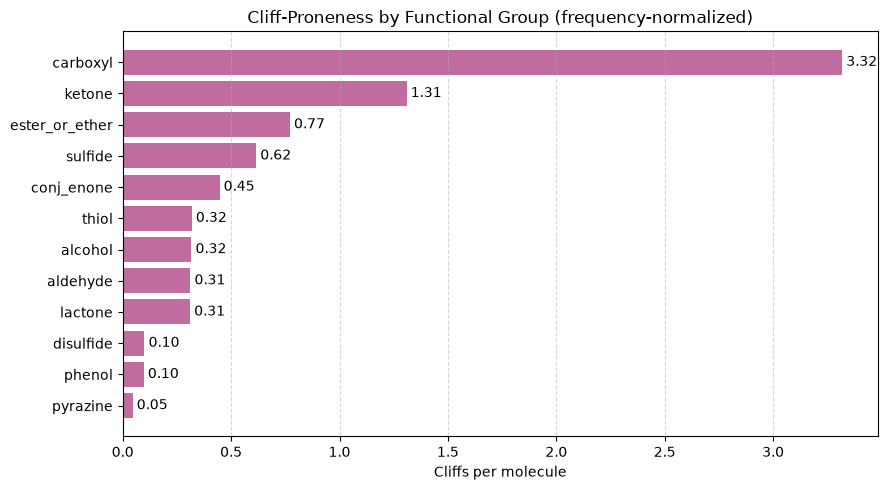

In [180]:
fig, ax = plt.subplots(figsize=(9, 5))

rate_sorted = rate_df.sort_values("cliffs_per_molecule", ascending=True)

bars = ax.barh(rate_sorted["group"], rate_sorted["cliffs_per_molecule"], color="#c06c9e")
ax.bar_label(bars, fmt="%.2f", padding=3)

ax.set_xlabel("Cliffs per molecule")
ax.set_title("Cliff-Proneness by Functional Group (frequency-normalized)")
ax.grid(True, axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [182]:
cliff_df["main_reason"] = cliff_df["reason"].apply(lambda r: r[0] if r else "other_unexplained")

top_reasons = cliff_df["main_reason"].value_counts().head(6).index
cliff_df["reason_grouped"] = cliff_df["main_reason"].apply(lambda r: r if r in top_reasons else "other")

print(cliff_df["reason_grouped"].value_counts())

reason_grouped
chain_length_or_size    171
ketone                  126
other_unexplained       106
ester                    88
other                    30
aldehyde                 24
conj_enone               18
Name: count, dtype: int64


In [187]:
#similarity based in Physchem properties
prop_cols = ["MW", "cLogP", "TPSA", "HBD", "HBA", "RotB", "AromaticRings", "FracCsp3", "BertzCT", "NumStereo"]

prop_matrix = labeled[prop_cols].values
prop_matrix_scaled = (prop_matrix - prop_matrix.mean(axis=0)) / prop_matrix.std(axis=0)

print(prop_matrix_scaled.shape)

(575, 10)


In [189]:
n = prop_matrix_scaled.shape[0]
prop_dist_matrix = np.zeros((n, n))

for i in range(n):
    diffs = prop_matrix_scaled[i] - prop_matrix_scaled   
    prop_dist_matrix[i] = np.sqrt((diffs ** 2).sum(axis=1))

prop_sim_matrix = 1 / (1 + prop_dist_matrix)

print(prop_sim_matrix.shape)
print(prop_sim_matrix[0, 1])

(575, 575)
0.3442910271383825


In [190]:
prop_dist_for_cluster = 1 - prop_sim_matrix

dist_list_prop = []
for i in range(1, n):
    for j in range(i):
        dist_list_prop.append(prop_dist_for_cluster[i, j])

clusters_prop = Butina.ClusterData(dist_list_prop, n, distThresh=0.6, isDistData=True)

print("Number of clusters (property-based):", len(clusters_prop))
print("Number of clusters (fingerprint-based):", len(clusters))

sizes_prop = [len(c) for c in clusters_prop]
print("Property-based singletons:", sum(1 for s in sizes_prop if s == 1))
print("Property-based largest cluster:", max(sizes_prop))

Number of clusters (property-based): 130
Number of clusters (fingerprint-based): 162
Property-based singletons: 57
Property-based largest cluster: 45


In [192]:
results_prop = []
for c in clusters_prop:
    if len(c) < 2:
        continue
    score = cluster_odor_consistency(c, labeled)
    results_prop.append({"cluster_size": len(c), "consistency": score, "members": c})

cluster_df_prop = pd.DataFrame(results_prop)
cluster_df_prop_sorted = cluster_df_prop.sort_values("consistency")

print(cluster_df_prop_sorted.head(10))

    cluster_size  consistency  \
28             2     0.000000   
70             2     0.000000   
68             2     0.000000   
25             3     0.027778   
53             3     0.030303   
33             3     0.047619   
21             2     0.062500   
52             2     0.090909   
12            19     0.093299   
8             16     0.101229   

                                              members  
28                                         (201, 438)  
70                                         (378, 197)  
68                                         (418, 338)  
25                                    (360, 156, 199)  
53                                     (127, 62, 552)  
33                                    (320, 214, 565)  
21                                         (336, 399)  
52                                          (233, 49)  
12  (253, 3, 6, 11, 16, 31, 86, 115, 135, 147, 150...  
8   (259, 68, 75, 83, 106, 186, 231, 232, 244, 311...  


In [193]:
labeled.loc[[201, 438]][["SMILES", "Odors"]]

,SMILES,Odors
201,CCC(C)C(=O)/C=C/C,"hazelnut, metallic, nutty"
438,CC(=C)[C@H]1CCC(=CC1)C=O,"minty, herbal, spicy, fatty, oily, fresh, gree..."


In [194]:
from rdkit.Chem import rdFMCS

mol_a = labeled.loc[0, "mol"]
mol_b = labeled.loc[1, "mol"]

mcs_result = rdFMCS.FindMCS([mol_a, mol_b])
print("Shared substructure SMARTS:", mcs_result.smartsString)
print("Number of atoms in common:", mcs_result.numAtoms)

Shared substructure SMARTS: [#6]-[#6]1=[#6]-[#6]-[#6](-[#6]-[#6]-1)-[#6](=[#6])-[#6]
Number of atoms in common: 10


In [195]:
def get_diff_description(i, j):
    mol_a = labeled.loc[i, "mol"]
    mol_b = labeled.loc[j, "mol"]
    try:
        mcs = rdFMCS.FindMCS([mol_a, mol_b], timeout=5)
    except Exception:
        return None

    atoms_a = mol_a.GetNumAtoms()
    atoms_b = mol_b.GetNumAtoms()
    shared = mcs.numAtoms

    extra_a = atoms_a - shared
    extra_b = atoms_b - shared

    return {
        "shared_atoms": shared,
        "extra_atoms_a": extra_a,
        "extra_atoms_b": extra_b,
        "mcs_smarts": mcs.smartsString
    }

mcs_results = []
for _, row in cliff_df.iterrows():
    result = get_diff_description(row["mol_i"], row["mol_j"])
    if result:
        result["mol_i"] = row["mol_i"]
        result["mol_j"] = row["mol_j"]
        mcs_results.append(result)

mcs_df = pd.DataFrame(mcs_results)
print(mcs_df.shape)
mcs_df.head()

(563, 6)


,shared_atoms,extra_atoms_a,extra_atoms_b,mcs_smarts,mol_i,mol_j
0,10,0,1,[#6]-[#6]1=[#6]-[#6]-[#6](-[#6]-[#6]-1)-[#6](=...,0,438
1,5,0,8,[#6]-[#6]-[#6]-[#6]-[#8],3,4
2,5,0,4,[#6]-[#6]-[#6]-[#6]-[#8],3,5
3,5,0,5,[#6]-[#6]-[#6]-[#6]-[#8],3,132
4,5,0,3,[#6]-[#6]-[#6]-[#6]-[#8],3,149


In [197]:
mcs_df["total_extra_atoms"] = mcs_df["extra_atoms_a"] + mcs_df["extra_atoms_b"]

print(mcs_df["total_extra_atoms"].describe())

# how many cliffs are driven by a single atom 
single_atom_cliffs = mcs_df[mcs_df["total_extra_atoms"] <= 1]
print("\nCliffs from a single-atom difference:", len(single_atom_cliffs))

count    563.000000
mean       6.412078
std        3.672636
min        0.000000
25%        4.000000
50%        6.000000
75%        9.000000
max       17.000000
Name: total_extra_atoms, dtype: float64

Cliffs from a single-atom difference: 29


In [198]:
single_atom_cliffs_full = mcs_df[mcs_df["total_extra_atoms"] <= 1]

for _, row in single_atom_cliffs_full.iterrows():
    i, j = row["mol_i"], row["mol_j"]
    print(f"--- shared_atoms={row['shared_atoms']}, extra_a={row['extra_atoms_a']}, extra_b={row['extra_atoms_b']} ---")
    print(labeled.loc[[i, j]][["SMILES", "Odors"]])
    print()

--- shared_atoms=10, extra_a=0, extra_b=1 ---
                       SMILES  \
0      CC1=CC[C@H](CC1)C(=C)C   
438  CC(=C)[C@H]1CCC(=CC1)C=O   

                                                 Odors  
0              terpenic, peppery, herbal, pine, orange  
438  minty, herbal, spicy, fatty, oily, fresh, gree...  

--- shared_atoms=12, extra_a=0, extra_b=1 ---
               SMILES                                              Odors
23    CCCCCCCC(=O)OCC  apricot, musty, winey, pear, brandy, dairy, pi...
372  CCCCCCCCC(=O)OCC  natural, tropical, fatty, oily, grape, nutty, ...

--- shared_atoms=8, extra_a=0, extra_b=1 ---
           SMILES                                              Odors
30    CCCCCC(=O)O                                cheesy, fatty, sour
373  CCCCCC(=O)OC  apricot, strawberry, pineapple, banana, fruity...

--- shared_atoms=12, extra_a=1, extra_b=0 ---
               SMILES                                              Odors
36   CCCCCCCCCC(=O)OC  fatty, winey, oily, f

In [199]:
labeled["inchi_no_bond_stereo"] = labeled["mol"].apply(
    lambda m: Chem.MolToInchi(m).split("/b")[0]
)

geom_groups = labeled.groupby("inchi_no_bond_stereo").filter(lambda g: len(g) > 1)
print("Molecules that are E/Z geometric isomers of something else:", len(geom_groups))
geom_groups.groupby("inchi_no_bond_stereo").size().sort_values(ascending=False)

Molecules that are E/Z geometric isomers of something else: 20


[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Charges were rearranged

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Charges were rearranged

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Omitted undefined stereo

[11:46:35] WARNING: Omitted undefine

inchi_no_bond_stereo
InChI=1S/C10H16O/c1-9(2)5-4-6-10(3)7-8-11/h5,7-8H,4,6H2,1-3H3                2
InChI=1S/C10H18O/c1-2-3-4-5-6-7-8-9-10-11/h6-7,10H,2-5,8-9H2,1H3             2
InChI=1S/C10H18O/c1-2-3-4-5-6-7-8-9-10-11/h8-10H,2-7H2,1H3                   2
InChI=1S/C10H18O/c1-9(2)5-4-6-10(3)7-8-11/h5,7,11H,4,6,8H2,1-3H3             2
InChI=1S/C12H20O2/c1-10(2)6-5-7-11(3)8-9-14-12(4)13/h6,8H,5,7,9H2,1-4H3      2
InChI=1S/C13H20O/c1-5-7-11(14)12-10(2)8-6-9-13(12,3)4/h5,7H,6,8-9H2,1-4H3    2
InChI=1S/C8H14O/c1-2-3-4-5-6-7-8-9/h6-8H,2-5H2,1H3                           2
InChI=1S/C9H14O/c1-2-3-4-5-6-7-8-9-10/h5-9H,2-4H2,1H3                        2
InChI=1S/C9H16O/c1-2-3-4-5-6-7-8-9-10/h3-4,7-8,10H,2,5-6,9H2,1H3             2
InChI=1S/C9H16O/c1-2-3-4-5-6-7-8-9-10/h7-9H,2-6H2,1H3                        2
dtype: int64

In [200]:
geom_scores = []
for skeleton, group in geom_groups.groupby("inchi_no_bond_stereo"):
    indices = group.index.tolist()
    score = cluster_odor_consistency(indices, labeled)
    geom_scores.append({"skeleton": skeleton, "n_isomers": len(indices), "consistency": score})

geom_score_df = pd.DataFrame(geom_scores).sort_values("consistency")
print(geom_score_df)

                                            skeleton  n_isomers  consistency
7  InChI=1S/C9H14O/c1-2-3-4-5-6-7-8-9-10/h5-9H,2-...          2     0.111111
8  InChI=1S/C9H16O/c1-2-3-4-5-6-7-8-9-10/h3-4,7-8...          2     0.125000
0  InChI=1S/C10H16O/c1-9(2)5-4-6-10(3)7-8-11/h5,7...          2     0.166667
6  InChI=1S/C8H14O/c1-2-3-4-5-6-7-8-9/h6-8H,2-5H2...          2     0.300000
2  InChI=1S/C10H18O/c1-2-3-4-5-6-7-8-9-10-11/h8-1...          2     0.300000
4  InChI=1S/C12H20O2/c1-10(2)6-5-7-11(3)8-9-14-12...          2     0.333333
3  InChI=1S/C10H18O/c1-9(2)5-4-6-10(3)7-8-11/h5,7...          2     0.375000
1  InChI=1S/C10H18O/c1-2-3-4-5-6-7-8-9-10-11/h6-7...          2     0.428571
9  InChI=1S/C9H16O/c1-2-3-4-5-6-7-8-9-10/h7-9H,2-...          2     0.625000
5  InChI=1S/C13H20O/c1-5-7-11(14)12-10(2)8-6-9-13...          2     0.666667


In [201]:
top2_skeletons = geom_score_df.head(2)["skeleton"].tolist()

for sk in top2_skeletons:
    print("---", sk[:50], "---")
    print(labeled[labeled["inchi_no_bond_stereo"] == sk][["SMILES", "Odors"]])
    print()

--- InChI=1S/C9H14O/c1-2-3-4-5-6-7-8-9-10/h5-9H,2-4H2, ---
               SMILES                                              Odors
174  CCCC/C=C/C=C/C=O  cucumber, fatty, chicken, melon, nutty, green,...
334  CCCC/C=C\C=C\C=O                           geranium, pungent, green

--- InChI=1S/C9H16O/c1-2-3-4-5-6-7-8-9-10/h3-4,7-8,10H ---
               SMILES                                              Odors
202  CC/C=C\CC/C=C/CO  herbal, cucumber, fatty, oily, violet, leafy, ...
321  CC/C=C/CC/C=C/CO                                              green



In [202]:
def get_ring_sizes(mol):
    ri = mol.GetRingInfo()
    return sorted([len(r) for r in ri.AtomRings()])

labeled["ring_sizes"] = labeled["mol"].apply(get_ring_sizes)

ring_size_cliffs = []
for _, row in cliff_df.iterrows():
    i, j = row["mol_i"], row["mol_j"]
    rings_i = labeled.loc[i, "ring_sizes"]
    rings_j = labeled.loc[j, "ring_sizes"]
    if len(rings_i) == 1 and len(rings_j) == 1 and abs(rings_i[0] - rings_j[0]) == 1:
        ring_size_cliffs.append({"mol_i": i, "mol_j": j, "ring_i": rings_i[0], "ring_j": rings_j[0]})

ring_size_df = pd.DataFrame(ring_size_cliffs)
print("Cliffs driven by a 1-atom ring size change:", len(ring_size_df))

Cliffs driven by a 1-atom ring size change: 11


In [203]:
for _, row in ring_size_df.iterrows():
    i, j = row["mol_i"], row["mol_j"]
    print(f"--- ring sizes: {row['ring_i']} vs {row['ring_j']} ---")
    print(labeled.loc[[i, j]][["SMILES", "Odors"]])
    print()

--- ring sizes: 5 vs 6 ---
                   SMILES                                              Odors
210   CCCCCCCCC1CCC(=O)O1              metallic, fatty, peach, sweet, fruity
545  CCCCCCCC1CC=CC(=O)O1  lactonic, fatty, buttery, dairy, coconut, waxy...

--- ring sizes: 5 vs 6 ---
                   SMILES                                              Odors
210   CCCCCCCCC1CCC(=O)O1              metallic, fatty, peach, sweet, fruity
557  CCCCCCCCC1CCCC(=O)O1  musty, fatty, milky, buttery, oily, dairy, creamy

--- ring sizes: 6 vs 5 ---
                  SMILES                                              Odors
216  CCCCCCCC1CCCC(=O)O1  apricot, tropical, metallic, fatty, milky, but...
538      CCCCCCC1CCCC1=O                     jasmine, floral, green, fruity

--- ring sizes: 6 vs 5 ---
                SMILES                                              Odors
340  CCCCCC1CCCC(=O)O1  lactonic, fatty, milky, buttery, oily, peach, ...
538    CCCCCCC1CCCC1=O                     jasmine,

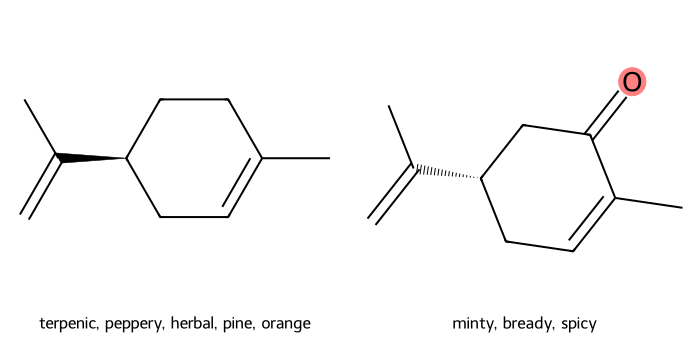

In [205]:
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

def draw_cliff_pair(i, j, filename):
    mol_a = labeled.loc[i, "mol"]
    mol_b = labeled.loc[j, "mol"]

    mcs = rdFMCS.FindMCS([mol_a, mol_b])
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)

    match_a = mol_a.GetSubstructMatch(mcs_mol)
    match_b = mol_b.GetSubstructMatch(mcs_mol)

    highlight_a = [atom.GetIdx() for atom in mol_a.GetAtoms() if atom.GetIdx() not in match_a]
    highlight_b = [atom.GetIdx() for atom in mol_b.GetAtoms() if atom.GetIdx() not in match_b]

    img = Draw.MolsToGridImage(
        [mol_a, mol_b],
        molsPerRow=2,
        subImgSize=(350, 350),
        legends=[labeled.loc[i, "Odors"][:40], labeled.loc[j, "Odors"][:40]],
        highlightAtomLists=[highlight_a, highlight_b],
        useSVG=False
    )

    if hasattr(img, "save"):
        img.save(filename)
    else:
        with open(filename, "wb") as f:
            f.write(img.data)

    return img

draw_cliff_pair(0, 1, "limonene_carvone.png")

In [206]:
examples = {
    "acid_to_ester": (162, 336),
    "sulfur_chain": (245, 313),
    "chain_length": (30, 373),
    "EZ_geometry": (174, 334),
}

for name, (i, j) in examples.items():
    print(f"Saving: {name}")
    draw_cliff_pair(i, j, f"{name}.png")

Saving: acid_to_ester
Saving: sulfur_chain
Saving: chain_length
Saving: EZ_geometry


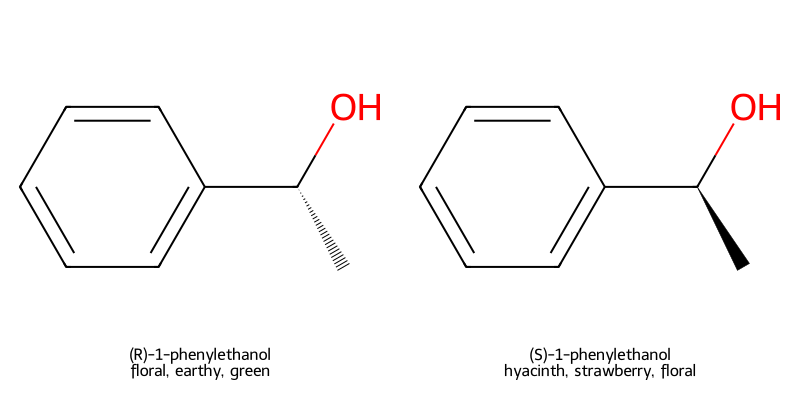

In [209]:
from rdkit.Chem import Draw

mol_a = labeled.loc[384, "mol"]
mol_b = labeled.loc[391, "mol"]

img = Draw.MolsToGridImage(
    [mol_a, mol_b],
    molsPerRow=2,
    subImgSize=(400, 400),
    legends=[
        f"(R)-1-phenylethanol\n{labeled.loc[384, 'Odors']}",
        f"(S)-1-phenylethanol\n{labeled.loc[391, 'Odors']}"
    ],
    useSVG=False
)
img

In [219]:
# PCA via numpy: center the data, do SVD, project onto top 2 components
X = prop_matrix_scaled  # already scaled, 575 x 10

U, S, Vt = np.linalg.svd(X, full_matrices=False)
pca_coords = U[:, :2] * S[:2]   # project onto first 2 principal components

print(pca_coords.shape)

(575, 2)


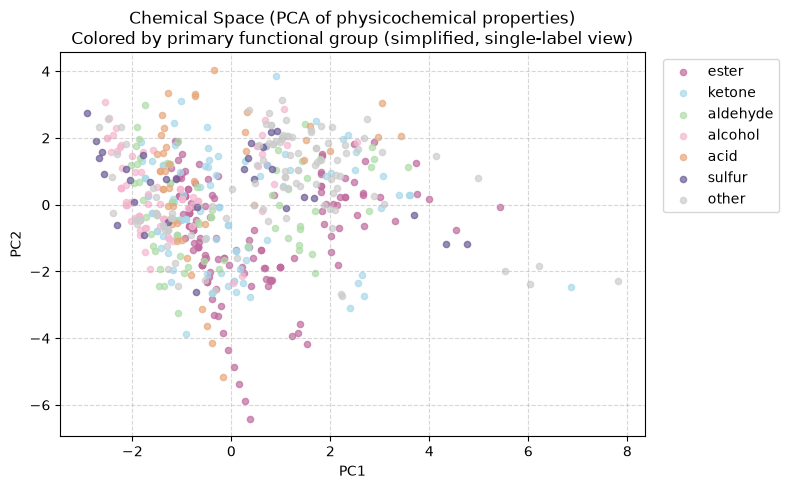

In [221]:
#Chemical class
fig, ax = plt.subplots(figsize=(8, 5))

class_colors = {
    "ester": "#c06c9e", "ketone": "#a8d8ea", "aldehyde": "#aedca8",
    "alcohol": "#f4b8d0", "acid": "#e8a87c", "sulfur": "#6b5b95", "other": "#cccccc"
}

for cls, color in class_colors.items():
    mask = labeled["chem_class"] == cls
    ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1], label=cls, color=color, alpha=0.7, s=20)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Chemical Space (PCA of physicochemical properties)\nColored by primary functional group (simplified, single-label view)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

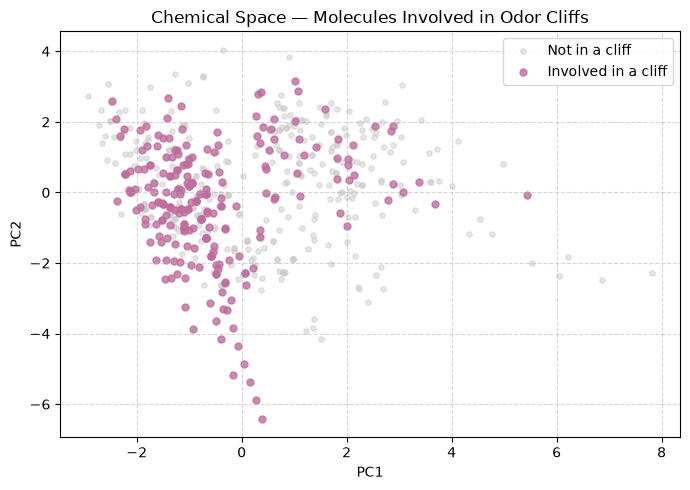

In [225]:
#Cliff involment
in_cliff = labeled.index.isin(set(cliff_df["mol_i"]) | set(cliff_df["mol_j"]))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pca_coords[~in_cliff, 0], pca_coords[~in_cliff, 1], color="#cccccc", alpha=0.5, s=15, label="Not in a cliff")
ax.scatter(pca_coords[in_cliff, 0], pca_coords[in_cliff, 1], color="#c06c9e", alpha=0.8, s=25, label="Involved in a cliff")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Chemical Space — Molecules Involved in Odor Cliffs")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

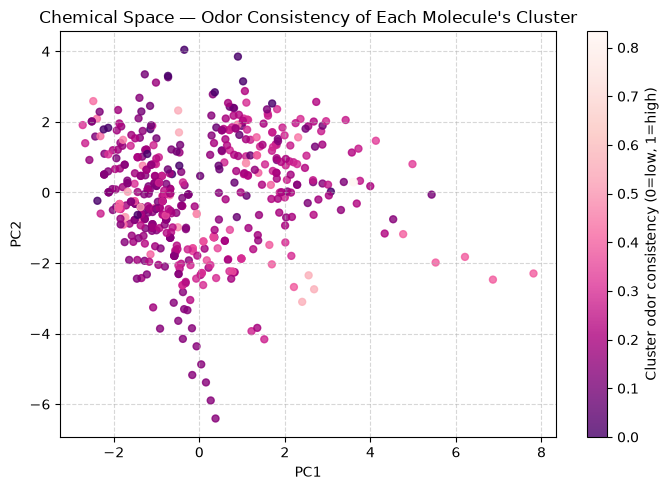

In [227]:
#odor consistency
mol_to_consistency = {}
for c in clusters:
    if len(c) < 2:
        continue
    score = cluster_odor_consistency(c, labeled)
    for idx in c:
        mol_to_consistency[idx] = score

consistency_values = labeled.index.map(lambda i: mol_to_consistency.get(i, np.nan))

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(pca_coords[:, 0], pca_coords[:, 1], c=consistency_values, cmap="RdPu_r", s=25, alpha=0.8)
plt.colorbar(sc, ax=ax, label="Cluster odor consistency (0=low, 1=high)")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Chemical Space — Odor Consistency of Each Molecule's Cluster")
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

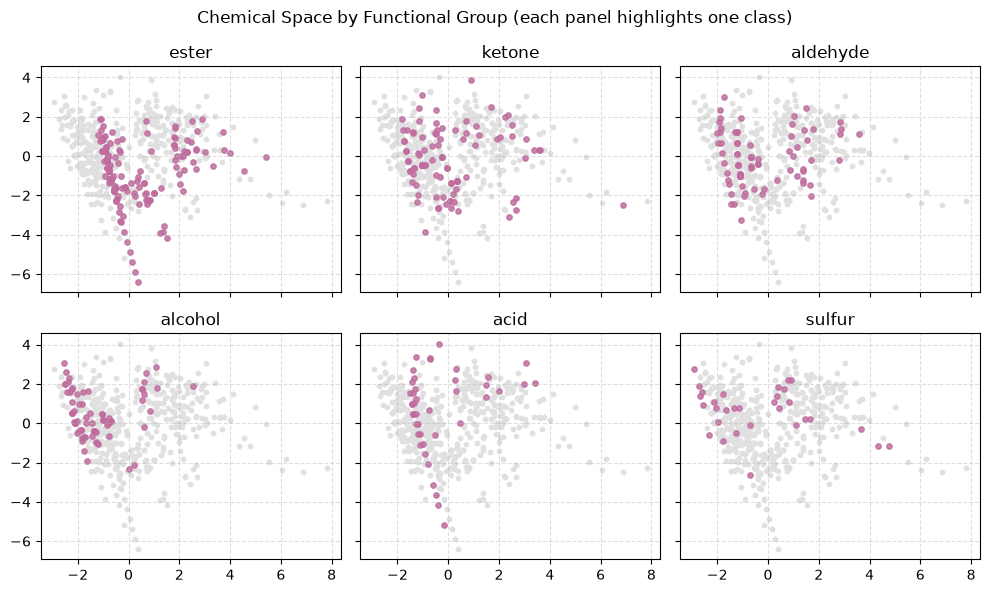

In [229]:
classes = ["ester", "ketone", "aldehyde", "alcohol", "acid", "sulfur"]

fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)

for ax, cls in zip(axes.flat, classes):
    ax.scatter(pca_coords[:, 0], pca_coords[:, 1], color="#e0e0e0", s=10)
    mask = labeled["chem_class"] == cls
    ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1], color="#c06c9e", s=15, alpha=0.8)
    ax.set_title(cls)
    ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Chemical Space by Functional Group (each panel highlights one class)")
plt.tight_layout()
plt.show()

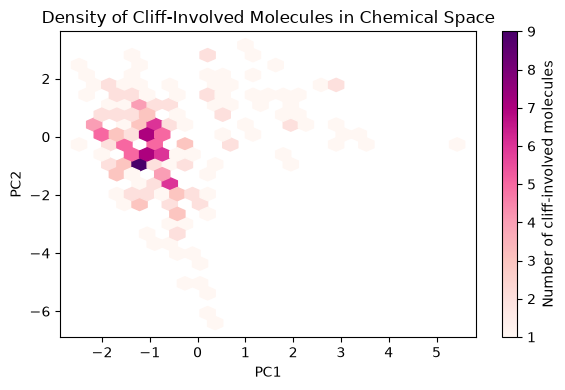

In [232]:
fig, ax = plt.subplots(figsize=(6, 4))

cliff_coords = pca_coords[in_cliff]
hb = ax.hexbin(cliff_coords[:, 0], cliff_coords[:, 1], gridsize=25, cmap="RdPu", mincnt=1)
plt.colorbar(hb, ax=ax, label="Number of cliff-involved molecules")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Density of Cliff-Involved Molecules in Chemical Space")

plt.tight_layout()
plt.show()

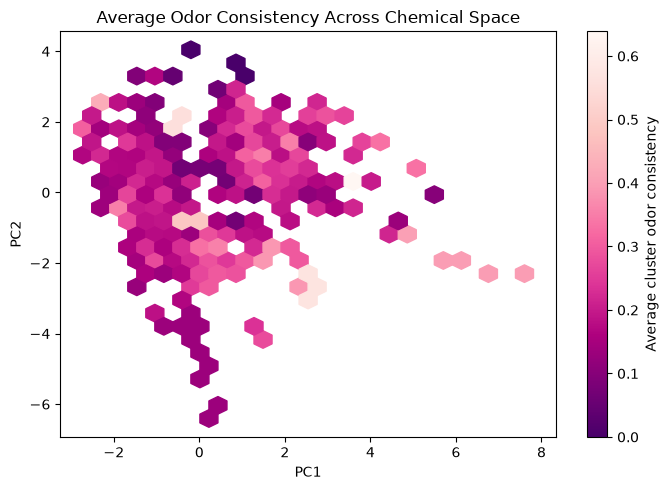

In [234]:
fig, ax = plt.subplots(figsize=(7, 5))

valid = ~np.isnan(consistency_values.astype(float))
hb = ax.hexbin(pca_coords[valid, 0], pca_coords[valid, 1],
               C=consistency_values[valid].astype(float),
               gridsize=25, cmap="RdPu_r", reduce_C_function=np.mean)
plt.colorbar(hb, ax=ax, label="Average cluster odor consistency")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Average Odor Consistency Across Chemical Space")

plt.tight_layout()
plt.show()

In [235]:
#Cheking the density plot
hotspot_mask = (pca_coords[:, 0] > -2) & (pca_coords[:, 0] < -0.5) & (pca_coords[:, 1] > -1.5) & (pca_coords[:, 1] < 0.5)
print(labeled.loc[hotspot_mask, "chem_class"].value_counts())

chem_class
ester       35
alcohol     31
other       26
aldehyde    23
ketone      23
acid        10
sulfur       4
Name: count, dtype: int64


In [236]:
# PCA based on morgan fingerprints
from rdkit import DataStructs

n_bits = 2048
fp_array = np.zeros((len(labeled), n_bits), dtype=np.int8)

for idx, fp in enumerate(labeled["fp"]):
    arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    fp_array[idx] = arr

print(fp_array.shape)

(575, 2048)


In [239]:
fp_mean = fp_array.mean(axis=0)
X_fp = fp_array - fp_mean  

U, S, Vt = np.linalg.svd(X_fp, full_matrices=False)
pca_coords_fp = U[:, :2] * S[:2]

print(pca_coords_fp.shape)

(575, 2)


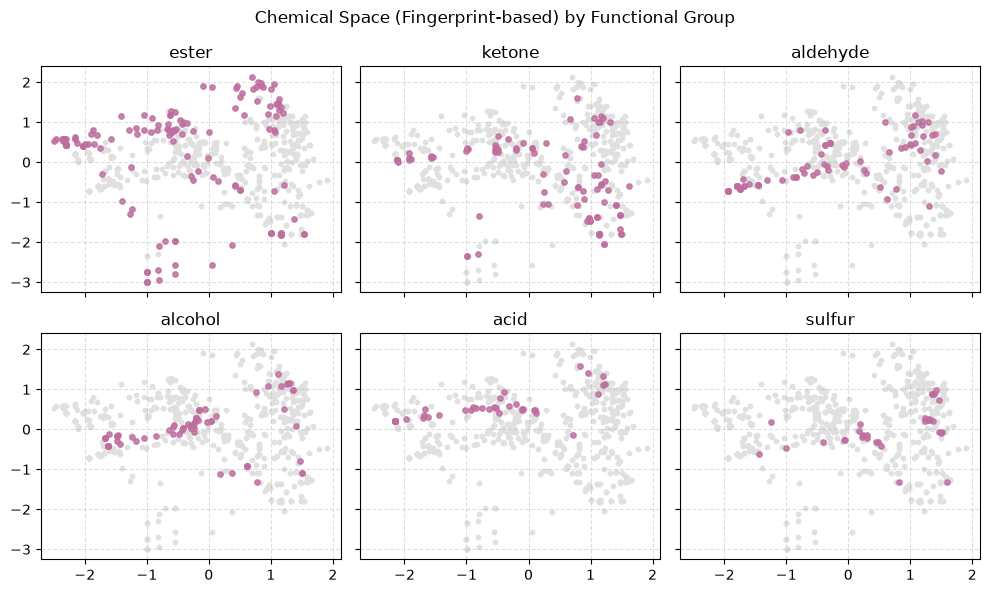

In [241]:
classes = ["ester", "ketone", "aldehyde", "alcohol", "acid", "sulfur"]

fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)

for ax, cls in zip(axes.flat, classes):
    ax.scatter(pca_coords_fp[:, 0], pca_coords_fp[:, 1], color="#e0e0e0", s=10)
    mask = labeled["chem_class"] == cls
    ax.scatter(pca_coords_fp[mask, 0], pca_coords_fp[mask, 1], color="#c06c9e", s=15, alpha=0.8)
    ax.set_title(cls)
    ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Chemical Space (Fingerprint-based) by Functional Group")
plt.tight_layout()
plt.show()

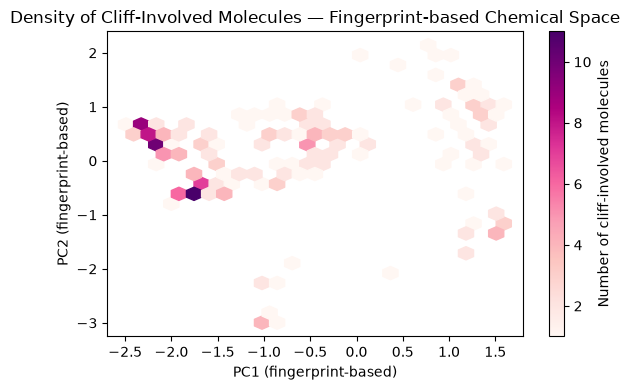

In [243]:
fig, ax = plt.subplots(figsize=(6, 4))

cliff_coords_fp = pca_coords_fp[in_cliff]
hb = ax.hexbin(cliff_coords_fp[:, 0], cliff_coords_fp[:, 1], gridsize=25, cmap="RdPu", mincnt=1)
plt.colorbar(hb, ax=ax, label="Number of cliff-involved molecules")

ax.set_xlabel("PC1 (fingerprint-based)")
ax.set_ylabel("PC2 (fingerprint-based)")
ax.set_title("Density of Cliff-Involved Molecules — Fingerprint-based Chemical Space")

plt.tight_layout()
plt.show()

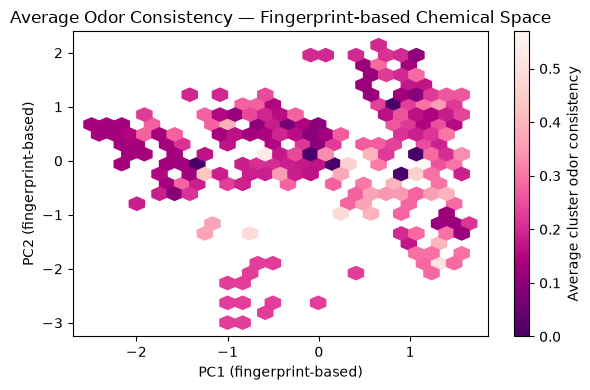

In [245]:
fig, ax = plt.subplots(figsize=(6, 4))

valid = ~np.isnan(consistency_values.astype(float))
hb = ax.hexbin(pca_coords_fp[valid, 0], pca_coords_fp[valid, 1],
               C=consistency_values[valid].astype(float),
               gridsize=25, cmap="RdPu_r", reduce_C_function=np.mean)
plt.colorbar(hb, ax=ax, label="Average cluster odor consistency")

ax.set_xlabel("PC1 (fingerprint-based)")
ax.set_ylabel("PC2 (fingerprint-based)")
ax.set_title("Average Odor Consistency — Fingerprint-based Chemical Space")

plt.tight_layout()
plt.show()

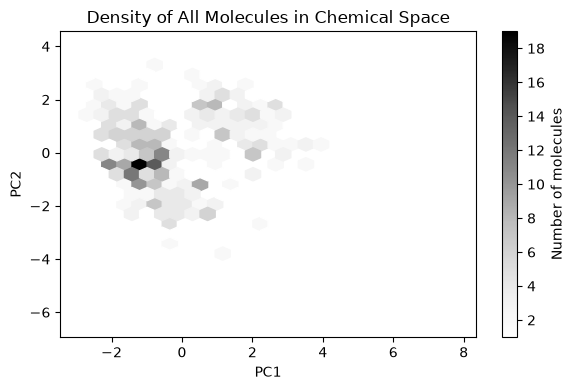

In [246]:
fig, ax = plt.subplots(figsize=(6, 4))

hb = ax.hexbin(
    pca_coords[:, 0],
    pca_coords[:, 1],
    gridsize=25,
    cmap="Greys",
    mincnt=1
)

plt.colorbar(hb, ax=ax, label="Number of molecules")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Density of All Molecules in Chemical Space")

plt.tight_layout()
plt.show()

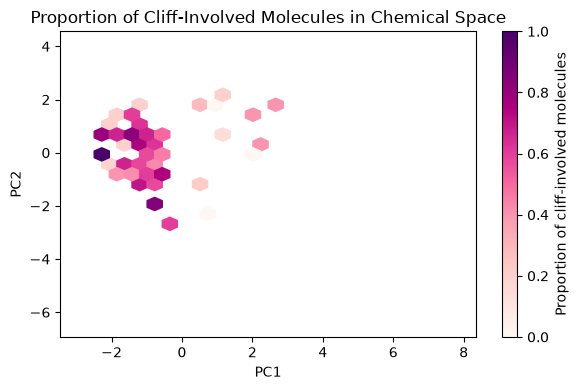

In [248]:
fig, ax = plt.subplots(figsize=(6, 4))

hb = ax.hexbin(
    pca_coords[:, 0],
    pca_coords[:, 1],
    C=in_cliff.astype(float),
    reduce_C_function=np.mean,
    gridsize=25,
    cmap="RdPu",
    mincnt=5,
    vmin=0,
    vmax=1
)

plt.colorbar(
    hb,
    ax=ax,
    label="Proportion of cliff-involved molecules"
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Proportion of Cliff-Involved Molecules in Chemical Space")

plt.tight_layout()
plt.show()

In [250]:
hb = ax.hexbin(
    pca_coords[:, 0],
    pca_coords[:, 1],
    C=in_cliff.astype(float),
    reduce_C_function=np.mean,
    gridsize=25,
    cmap="RdPu",
    mincnt=5,
    vmin=0,
    vmax=1
)
overall_proportion = np.mean(in_cliff)

print("Overall cliff proportion:", overall_proportion)

Overall cliff proportion: 0.40869565217391307


In [251]:
shuffled_cliff = np.random.permutation(in_cliff)

print("Original:")
print(in_cliff[:10])

print("\nShuffled:")
print(shuffled_cliff[:10])

print("\nOriginal proportion:", np.mean(in_cliff))
print("Shuffled proportion:", np.mean(shuffled_cliff))

Original:
[ True False False  True  True  True  True  True False False]

Shuffled:
[ True False False False False False False  True  True False]

Original proportion: 0.40869565217391307
Shuffled proportion: 0.40869565217391307


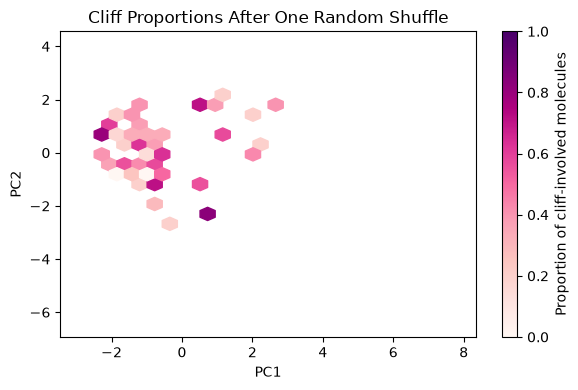

In [252]:
fig, ax = plt.subplots(figsize=(6, 4))

hb = ax.hexbin(
    pca_coords[:, 0],
    pca_coords[:, 1],
    C=shuffled_cliff.astype(float),   # shuffled labels
    reduce_C_function=np.mean,
    gridsize=25,
    cmap="RdPu",
    mincnt=5,
    vmin=0,
    vmax=1
)

plt.colorbar(
    hb,
    ax=ax,
    label="Proportion of cliff-involved molecules"
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Cliff Proportions After One Random Shuffle")

plt.tight_layout()
plt.show()

P-values:
[0.97150285 0.92610739 0.11508849 0.92870713 0.05759424 0.10068993
 0.05269473 0.18768123 0.9290071  0.01979802 0.30626937 0.54714529
 0.18558144 0.34126587 0.93780622 0.85581442 1.         0.68053195
 0.68333167 0.01139886 0.09279072 0.68273173 0.1949805  0.93130687
 0.5870413  0.04239576 0.33286671 0.33066693 0.31036896 0.19158084
 0.05289471 0.5020498  0.47855214 1.         0.97450255 0.92540746
 1.         0.68593141]


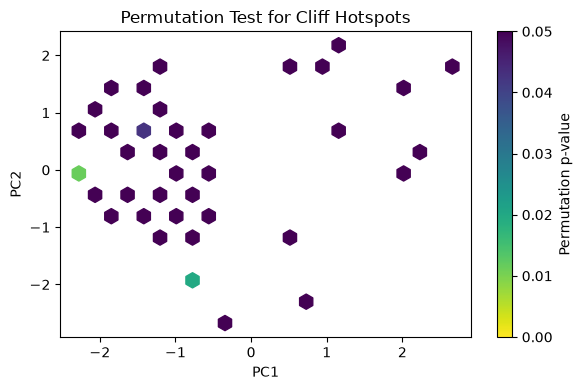


Hexagons with p < 0.05:
PC1 = -0.77 | PC2 = -1.93 | Cliff proportion = 0.86 | p-value = 0.0198
PC1 = -2.28 | PC2 = -0.06 | Cliff proportion = 1.0 | p-value = 0.0114
PC1 = -1.42 | PC2 = 0.68 | Cliff proportion = 0.83 | p-value = 0.0424


In [254]:

n_permutations = 10000
gridsize = 25
min_molecules = 5


#  ------------------------------------------

fig, ax = plt.subplots()

hb_real = ax.hexbin(
    pca_coords[:, 0],
    pca_coords[:, 1],
    C=in_cliff.astype(float),
    reduce_C_function=np.mean,
    gridsize=gridsize,
    mincnt=min_molecules
)

# Real cliff proportion in each hexagon
observed_proportions = hb_real.get_array()

# Coordinates of the hexagons
hex_centers = hb_real.get_offsets()

plt.close(fig)


# ------------------------------------------
# 2. PERMUTATIONS
# ------------------------------------------

# Count how many random permutations give a proportion
# >= the real proportion in each hexagon
more_extreme = np.zeros(len(observed_proportions))


for i in range(n_permutations):

    # Randomly shuffle cliff / non-cliff labels
    shuffled_cliff = np.random.permutation(in_cliff)

    fig, ax = plt.subplots()

    hb_shuffle = ax.hexbin(
        pca_coords[:, 0],
        pca_coords[:, 1],
        C=shuffled_cliff.astype(float),
        reduce_C_function=np.mean,
        gridsize=gridsize,
        mincnt=min_molecules
    )

    shuffled_proportions = hb_shuffle.get_array()

    plt.close(fig)

    # Compare random values with the real values
    more_extreme += (
        shuffled_proportions >= observed_proportions
    )


# ------------------------------------------
# 3. CALCULATE P-VALUES
# ------------------------------------------

p_values = (more_extreme + 1) / (n_permutations + 1)

print("P-values:")
print(p_values)


# plot

fig, ax = plt.subplots(figsize=(6, 4))

scatter = ax.scatter(
    hex_centers[:, 0],
    hex_centers[:, 1],
    c=p_values,
    cmap="viridis_r",
    vmin=0,
    vmax=0.05,
    marker="h",
    s=120
)

plt.colorbar(
    scatter,
    ax=ax,
    label="Permutation p-value"
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Permutation Test for Cliff Hotspots")

plt.tight_layout()
plt.show()

print("\nHexagons with p < 0.05:")

for i in range(len(p_values)):
    if p_values[i] < 0.05:
        print(
            "PC1 =", round(hex_centers[i, 0], 2),
            "| PC2 =", round(hex_centers[i, 1], 2),
            "| Cliff proportion =", round(observed_proportions[i], 2),
            "| p-value =", round(p_values[i], 4)
        )

In [258]:

# FDR Correction (Benjamini-Hochberg) (By NumPy)

# Number of p-values / hexagons tested
m = len(p_values)

# Sort the p-values
order = np.argsort(p_values)
sorted_p = p_values[order]

# Calculate FDR-adjusted p-values
adjusted_sorted = sorted_p * m / np.arange(1, m + 1)

# Make sure adjusted p-values don't decrease
adjusted_sorted = np.minimum.accumulate(adjusted_sorted[::-1])[::-1]

# P-values cannot be greater than 1
adjusted_sorted = np.minimum(adjusted_sorted, 1)

# Put them back in the original hexagon order
p_values_fdr = np.empty(m)
p_values_fdr[order] = adjusted_sorted


# Print hexagons significant after FDR correction
print("Hexagons significant after FDR correction:")

for i in range(m):
    if p_values_fdr[i] < 0.05:
        print(
            "PC1 =", round(hex_centers[i, 0], 2),
            "| PC2 =", round(hex_centers[i, 1], 2),
            "| Cliff proportion =", round(observed_proportions[i], 2),
            "| Original p =", round(p_values[i], 4),
            "| FDR-adjusted p =", round(p_values_fdr[i], 4)
        )
        
   # print("\nCandidate hexagons before and after FDR correction:")

for i in range(len(p_values)):
    if p_values[i] < 0.05:
        print(
            "PC1 =", round(hex_centers[i, 0], 2),
            "| PC2 =", round(hex_centers[i, 1], 2),
            "| Cliff proportion =", round(observed_proportions[i], 2),
            "| Original p =", round(p_values[i], 4),
            "| FDR-adjusted p =", round(p_values_fdr[i], 4)
        )

Hexagons significant after FDR correction:
PC1 = -0.77 | PC2 = -1.93 | Cliff proportion = 0.86 | Original p = 0.0198 | FDR-adjusted p = 0.3648
PC1 = -2.28 | PC2 = -0.06 | Cliff proportion = 1.0 | Original p = 0.0114 | FDR-adjusted p = 0.3648
PC1 = -1.42 | PC2 = 0.68 | Cliff proportion = 0.83 | Original p = 0.0424 | FDR-adjusted p = 0.3648


In [259]:
# Find the candidate hexagons
candidate_indices = np.where(p_values < 0.05)[0]

print("Candidate hexagons:\n")

for i in candidate_indices:

    # Cliff proportion in this hexagon
    proportion = observed_proportions[i]

    # Find the number of molecules in this hexagon
    # by making a count-based hexbin with the same settings
    fig, ax = plt.subplots()

    hb_count = ax.hexbin(
        pca_coords[:, 0],
        pca_coords[:, 1],
        gridsize=25,
        mincnt=5
    )

    count_centers = hb_count.get_offsets()
    counts = hb_count.get_array()

    plt.close(fig)

    # Find the matching hexagon
    distances = np.linalg.norm(
        count_centers - hex_centers[i],
        axis=1
    )

    j = np.argmin(distances)

    total = int(counts[j])

    # Number of cliff-involved molecules
    n_cliff = int(round(proportion * total))

    print(
        "PC1 =", round(hex_centers[i, 0], 2),
        "| PC2 =", round(hex_centers[i, 1], 2),
        "| Total molecules =", total,
        "| Cliff molecules =", n_cliff,
        "| Proportion =", round(proportion, 2),
        "| FDR p =", round(p_values_fdr[i], 4)
    )

Candidate hexagons:

PC1 = -0.77 | PC2 = -1.93 | Total molecules = 7 | Cliff molecules = 6 | Proportion = 0.86 | FDR p = 0.3648
PC1 = -2.28 | PC2 = -0.06 | Total molecules = 5 | Cliff molecules = 5 | Proportion = 1.0 | FDR p = 0.3648
PC1 = -1.42 | PC2 = 0.68 | Total molecules = 6 | Cliff molecules = 5 | Proportion = 0.83 | FDR p = 0.3648
